# Project 2 — Insurance Reviews NLP Pipeline

**Goal:** Build a complete supervised NLP pipeline on 34,999 French insurance reviews.
- Primary task: predict star rating (1–5)
- Secondary: zero-shot category detection

**Phases:**
1. Data Loading & EDA
2. Preprocessing & Topic Modeling (LDA)
3. Embeddings (Word2Vec + GloVe)
4. Supervised Models
5. Streamlit App (see `app.py`)

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, glob
# Disable TensorFlow (AVX not available on this machine)
os.environ['USE_TF'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams['figure.figsize'] = (10, 5)
DATA_DIR = 'Traduction avis clients'
print('Setup OK')


Setup OK


---
## Phase 1 — Data Loading & EDA

In [2]:
# ── 1.1 Load all 35 Excel files ────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, 'avis_*_traduit.xlsx')))
print(f'Found {len(files)} files')

dfs = []
for f in files:
    tmp = pd.read_excel(f)
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(f'Total rows: {len(df):,}  |  Columns: {df.columns.tolist()}')
df.head(7)

Found 35 files
Total rows: 34,435  |  Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,03/03/2020,01/03/2020,The GMF has been waiting for a water damage fo...,NaN,NaN
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,28/08/2021,01/08/2021,I am good with this insurance. She is practica...,NaN,NaN
5,5.0,ilyas-k-115898,Le drive box nest pas tres fiable.Ca demande b...,Direct Assurance,auto,train,03/06/2021,01/06/2021,The Drive Box is not very reliable.ca requests...,NaN,NaN
6,5.0,nadette-121889,J'ai malheureusement eu à faire appel à plusie...,Pacifica,auto,train,30/06/2021,01/06/2021,"Unfortunately, I had to call on Pacifica for b...",NaN,NaN


In [3]:
# ── 1.2 Basic stats ─────────────────────────────────────────────────────────
print('====================== Shape ')
print(df.shape)
print('\n==================== dtypes')
print(df.dtypes)
print('\n================ Null counts ')
print(df.isnull().sum())

====================== Shape 
(34435, 11)

==================== dtypes
note                float64
auteur               object
avis                 object
assureur             object
produit              object
type                 object
date_publication     object
date_exp             object
avis_en              object
avis_cor             object
avis_cor_en          object
dtype: object

================ Null counts 
note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
dtype: int64


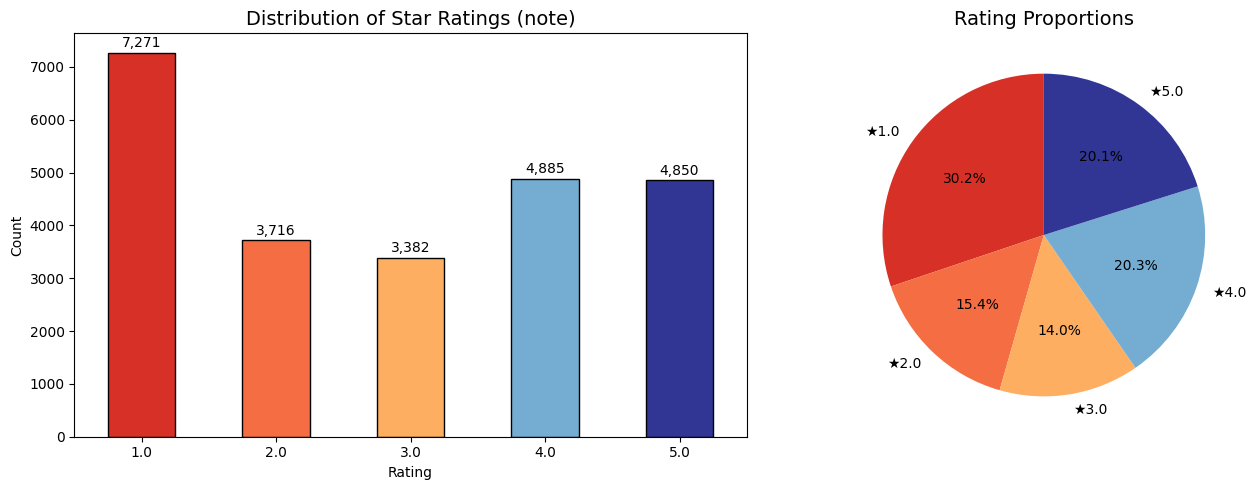

In [4]:
# ── 1.3 Note distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

note_counts = df['note'].value_counts().sort_index()
colors = ['#d73027', '#f46d43', '#fdae61', '#74add1', '#313695']
note_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribution of Star Ratings (note)', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar, count in zip(axes[0].patches, note_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(note_counts.values, labels=[f'★{i}' for i in note_counts.index],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Rating Proportions', fontsize=14)
plt.tight_layout()
plt.savefig('fig_note_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

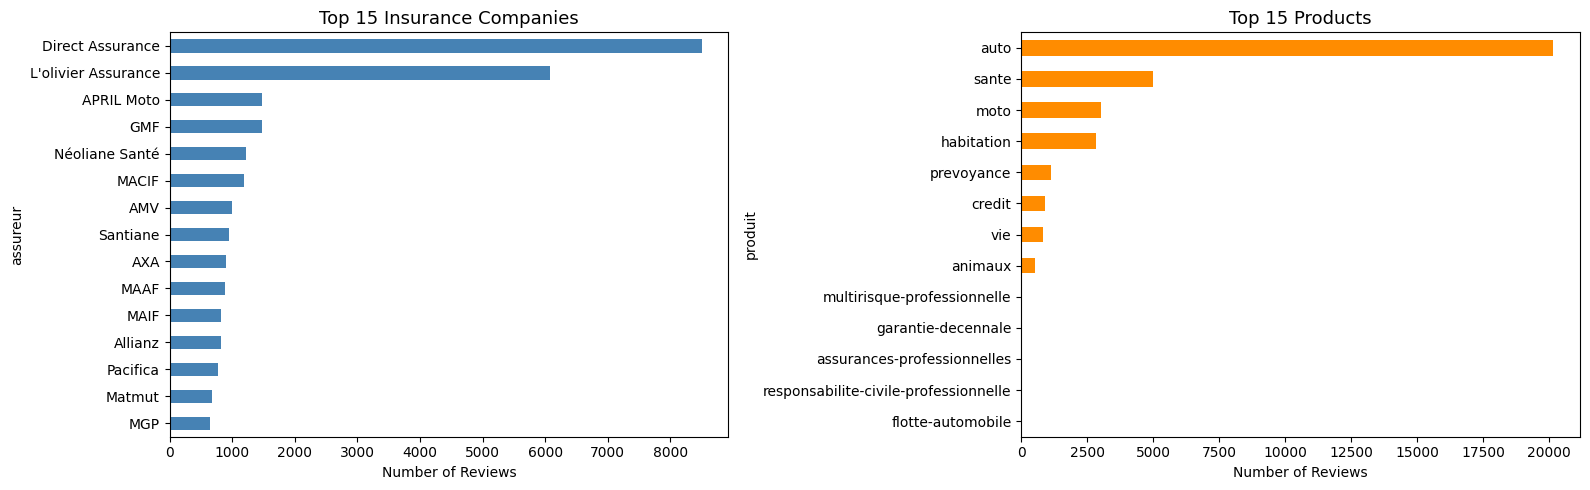

In [5]:
# ── 1.4 Top assureurs ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_assureurs = df['assureur'].value_counts().head(15)
top_assureurs.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Insurance Companies', fontsize=13)
axes[0].set_xlabel('Number of Reviews')
axes[0].invert_yaxis()

top_produits = df['produit'].value_counts().head(15)
top_produits.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 Products', fontsize=13)
axes[1].set_xlabel('Number of Reviews')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig_assureurs_produits.png', dpi=150, bbox_inches='tight')
plt.show()

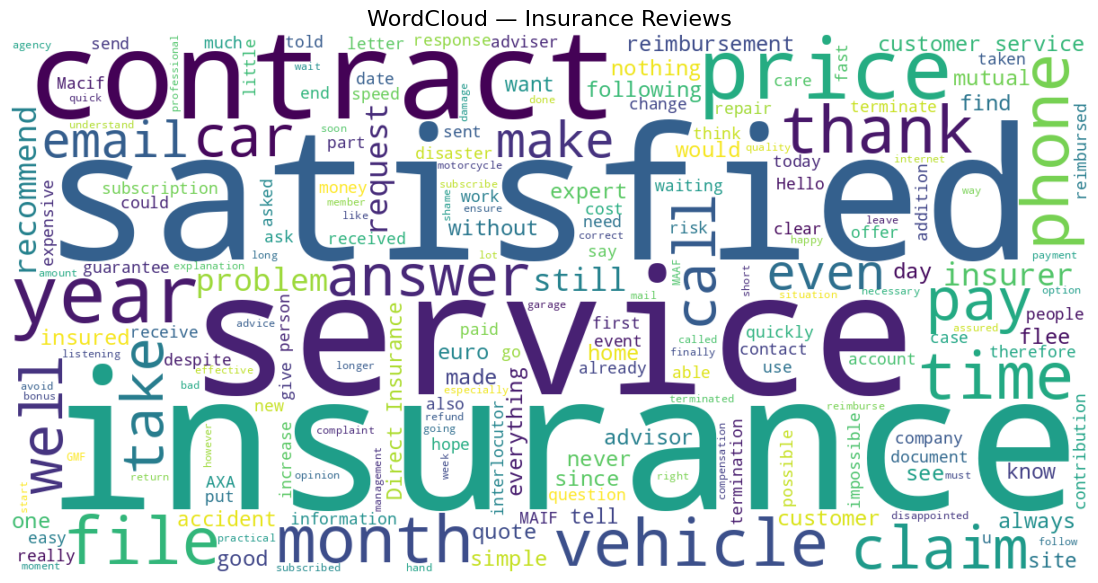

In [6]:
# ── 1.5 WordCloud on avis_en ────────────────────────────────────────────────
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# avis_en is the primary text column (avis_cor_en is mostly null)
text_col = 'avis_en'
corpus_text = ' '.join(df[text_col].dropna().astype(str).tolist())

wc = WordCloud(width=1200, height=600, background_color='white',
               stopwords=stop_words, max_words=200, colormap='viridis')
wc.generate(corpus_text)

plt.figure(figsize=(16, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Insurance Reviews', fontsize=16)
plt.savefig('fig_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

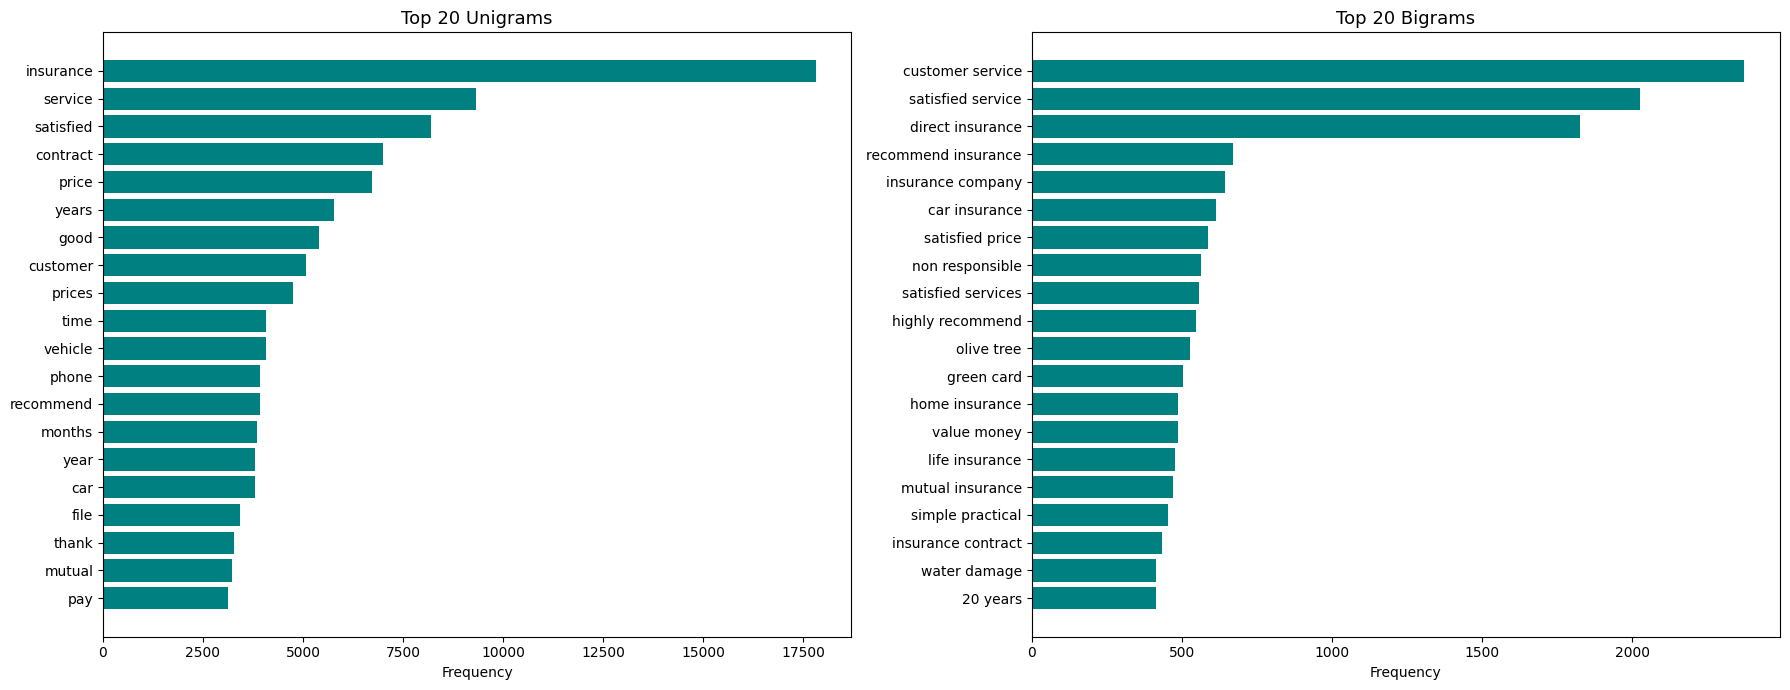

✅ Phase 1 complete


In [7]:
# ── 1.6 Top N-grams ─────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

sample_texts = df[text_col].dropna().astype(str).tolist()

def plot_ngrams(texts, n, top_k=20, ax=None, title=''):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    X = vec.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top_idx = freqs.argsort()[-top_k:][::-1]
    top_words = [vocab[i] for i in top_idx]
    top_freq = [freqs[i] for i in top_idx]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_words[::-1], top_freq[::-1], color='teal')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Frequency')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_ngrams(sample_texts, 1, ax=axes[0], title='Top 20 Unigrams')
plot_ngrams(sample_texts, 2, ax=axes[1], title='Top 20 Bigrams')
plt.tight_layout()
plt.savefig('fig_ngrams.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Phase 1 complete')

In [8]:
# ── 1.7 Spelling Correction ─────────────────────────────────────────────────
# The dataset already contains pre-corrected columns:
#   avis     → original French review
#   avis_cor → spell-corrected French review  ← built-in correction
#   avis_en  → English translation of original
# We highlight differences between avis and avis_cor to show corrections applied.

import difflib

sample = df[df['avis'].notnull() & df['avis_cor'].notnull()].head(200)
corrections_found = []
for _, row in sample.iterrows():
    orig = str(row['avis'])
    corr = str(row['avis_cor'])
    if orig != corr:
        # Find changed tokens
        orig_words = orig.split()
        corr_words = corr.split()
        changes = [(a, b) for a, b in zip(orig_words, corr_words) if a != b][:3]
        if changes:
            corrections_found.append({'original': orig[:120], 'corrected': corr[:120], 'changes': changes})

print(f"Corrections found in sample: {len(corrections_found)} / {len(sample)} reviews\n")
for ex in corrections_found[:5]:
    print(f"  Original : {ex['original']}")
    print(f"  Corrected: {ex['corrected']}")
    print(f"  Changes  : {ex['changes']}\n")

# Stats: how many reviews differ between avis and avis_cor
n_changed = (df['avis'].astype(str) != df['avis_cor'].astype(str)).sum()
print(f"Total reviews with corrections: {n_changed:,} / {df['avis'].notnull().sum():,} ({n_changed/df['avis'].notnull().sum():.1%})")
print("\n→ avis_en (English translation) is based on avis_cor — corrections are already propagated.")


Corrections found in sample: 2 / 200 reviews

  Original : A fuire j'ai été en arrêt cas contact  covid 2 semaines plus une semaine de prolongations par mon médecin traitant pour 
  Corrected: A fuir j'ai été en arrêt cas contact  covid 2 semaines plus une semaine de prolongations par mon médecin traitant pour c
  Changes  : [('fuire', 'fuir')]

  Original : je suis en retraite depuis le 1 janvier , toujours rien recu , assurance retraite a fuire , personnel sans aucun pouvoir
  Corrected: je suis en retraite depuis le 1 janvier , toujours rien recu , assurance retraite a fuir , personnel sans aucun pouvoir 
  Changes  : [('fuire', 'fuir')]

Total reviews with corrections: 34,002 / 34,435 (98.7%)

→ avis_en (English translation) is based on avis_cor — corrections are already propagated.


---
## Phase 2 — Preprocessing & Topic Modeling (LDA)

In [9]:
# ── 2.1 Text cleaning ───────────────────────────────────────────────────────
import re
import string
import spacy
from nltk.corpus import stopwords

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
stop_words_en = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    text = text.lower()
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)     # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # normalize whitespace
    return text

def lemmatize_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc
                if token.lemma_ not in stop_words_en
                and len(token.lemma_) > 2
                and not token.is_space]
    return ' '.join(tokens)

# Apply on avis_cor_en (use smaller batch for spacy pipe)
print('Cleaning texts...')
df['text_clean_raw'] = df[text_col].apply(clean_text)

print('Lemmatizing (this may take ~2-3 minutes)...')
# Use spacy pipe for speed
texts_to_lemmatize = df['text_clean_raw'].tolist()
lemmatized = []
batch_size = 500
for i in range(0, len(texts_to_lemmatize), batch_size):
    batch = texts_to_lemmatize[i:i+batch_size]
    for doc in nlp.pipe(batch, batch_size=64):
        tokens = [t.lemma_ for t in doc
                    if t.lemma_ not in stop_words_en
                    and len(t.lemma_) > 2
                    and not t.is_space]
        lemmatized.append(' '.join(tokens))
    if (i // batch_size) % 10 == 0:
        print(f'  {i:,}/{len(texts_to_lemmatize):,}')

df['text_clean'] = lemmatized
print(f'\nSample cleaned text:\n{df["text_clean"].iloc[0][:200]}')
print(f'\nNull in text_clean: {df["text_clean"].apply(lambda x: x == "").sum()}')

Cleaning texts...
Lemmatizing (this may take ~2-3 minutes)...
  0/34,435
  5,000/34,435
  10,000/34,435
  15,000/34,435
  20,000/34,435
  25,000/34,435
  30,000/34,435

Sample cleaned text:
person phone clear friendly explain everything would recommend insurance without hesitation thank person contact

Null in text_clean: 10


In [10]:
# ── 2.1b Export clean file ───────────────────────────────────────────────────
# Produce a file with all cleaned/translated columns
cols_to_keep = ['note', 'assureur', 'produit', 'type', 'date_publication',
                'avis', 'avis_en', 'avis_corrected', 'text_clean']
df_export = df[[c for c in cols_to_keep if c in df.columns]].copy()
df_export.to_csv('reviews_cleaned.csv', index=False, encoding='utf-8')
print(f"Saved reviews_cleaned.csv — {len(df_export):,} rows, columns: {df_export.columns.tolist()}")
df_export.head(3)


Saved reviews_cleaned.csv — 34,435 rows, columns: ['note', 'assureur', 'produit', 'type', 'date_publication', 'avis', 'avis_en', 'text_clean']


,note,assureur,produit,type,date_publication,avis,avis_en,text_clean
0,4.0,L'olivier Assurance,auto,train,06/10/2021,La personne au téléphone était Clair et sympat...,The person on the phone was clear and friendly...,person phone clear friendly explain everything...
1,4.0,APRIL Moto,moto,train,09/07/2021,"Satisfait.\n\nRéactivité, simplicité. Prix att...","Satisfied.\n\nReactivity, simplicity. Attracti...",satisfied reactivity simplicity attractive pri...
2,1.0,SwissLife,vie,train,15/10/2020,"Assureur à fuir, n assure pas ses responsabili...","Insurer to flee, does not ensure its responsib...",insurer flee ensure responsibility insurance a...


In [11]:
# ── 2.2 LDA Topic Modeling ──────────────────────────────────────────────────
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# Build corpus
tokenized = [t.split() for t in df['text_clean'] if len(t.split()) >= 3]
dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(t) for t in tokenized]
print(f'Dictionary size: {len(dictionary)} | Corpus docs: {len(corpus)}')

# Test K=5,7,10
coherence_scores = {}
models = {}

for k in [5, 7, 10]:
    print(f'Training LDA K={k}...')
    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                   random_state=42, passes=5, chunksize=2000, alpha='auto')
    cm_model = CoherenceModel(model=lda, texts=tokenized,
                               dictionary=dictionary, coherence='c_v')
    score = cm_model.get_coherence()
    coherence_scores[k] = score
    models[k] = lda
    print(f'  K={k} coherence: {score:.4f}')

best_k = max(coherence_scores, key=coherence_scores.get)
print(f'\nBest K = {best_k} (coherence = {coherence_scores[best_k]:.4f}')

Dictionary size: 5348 | Corpus docs: 33113
Training LDA K=5...
  K=5 coherence: 0.5014
Training LDA K=7...
  K=7 coherence: 0.5170
Training LDA K=10...
  K=10 coherence: 0.5058

Best K = 7 (coherence = 0.5170


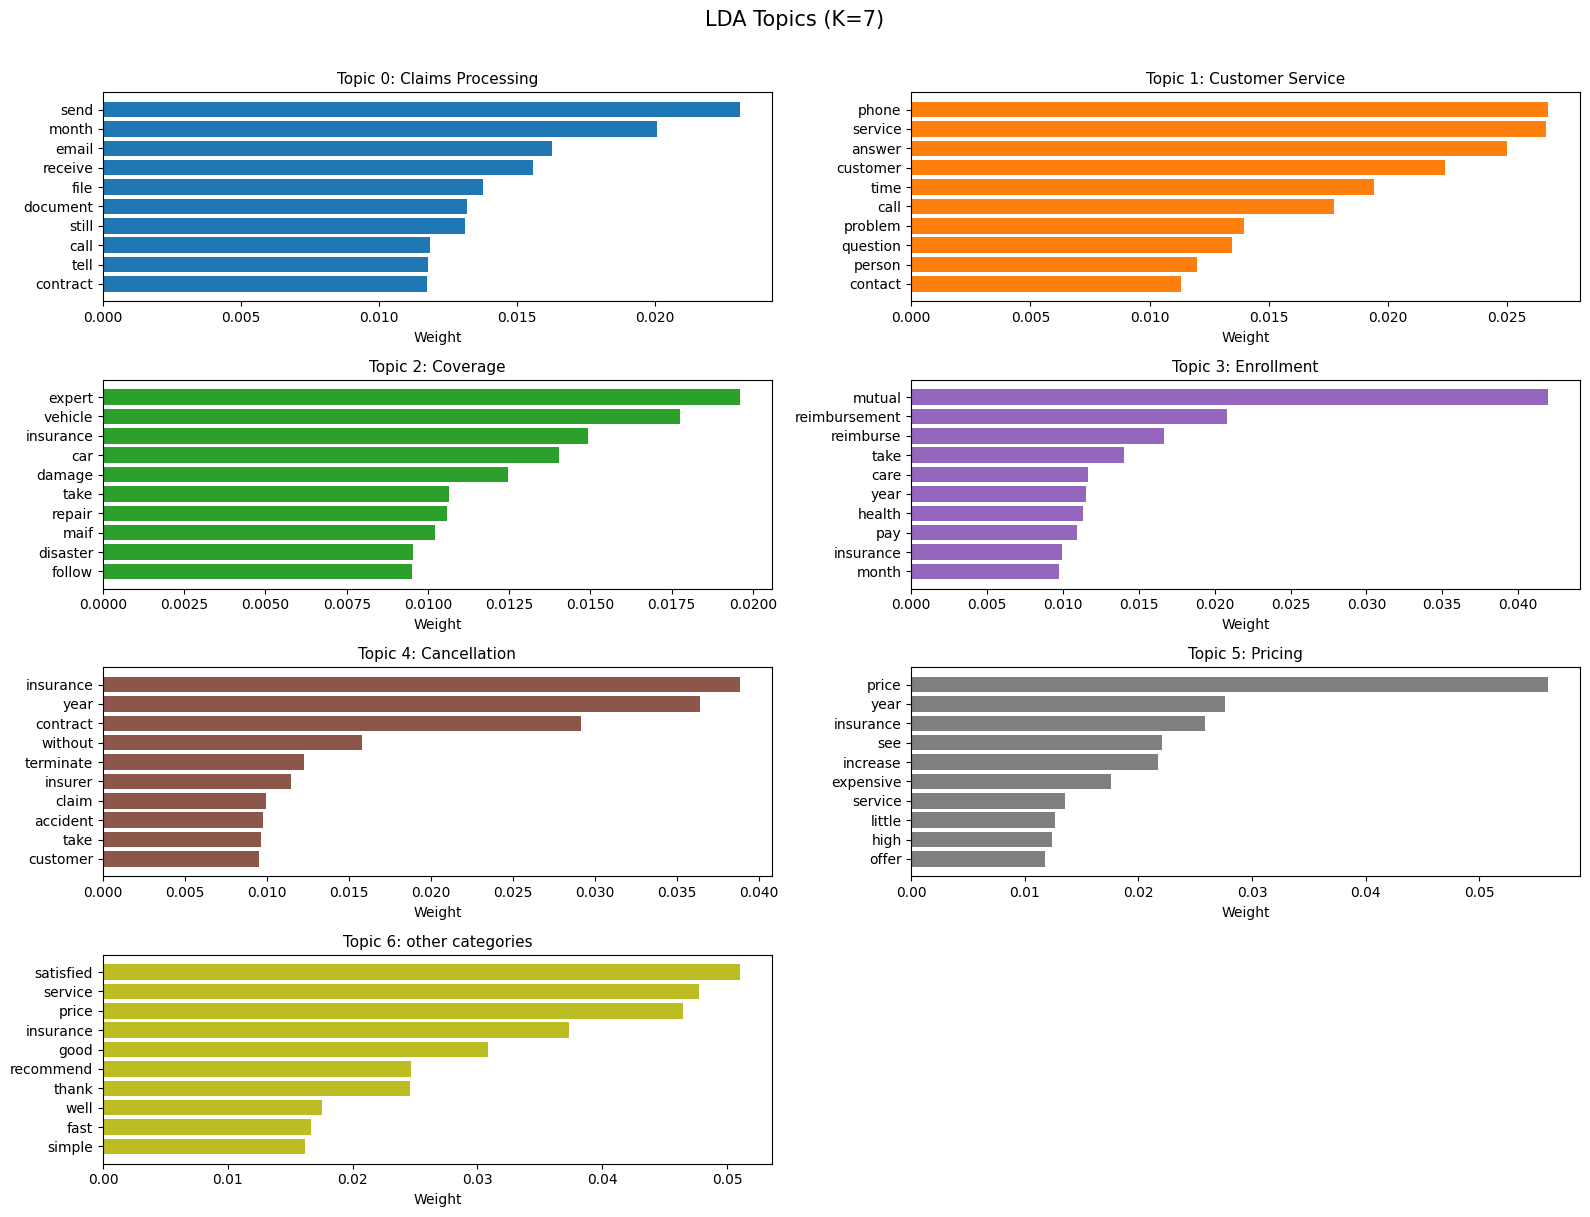

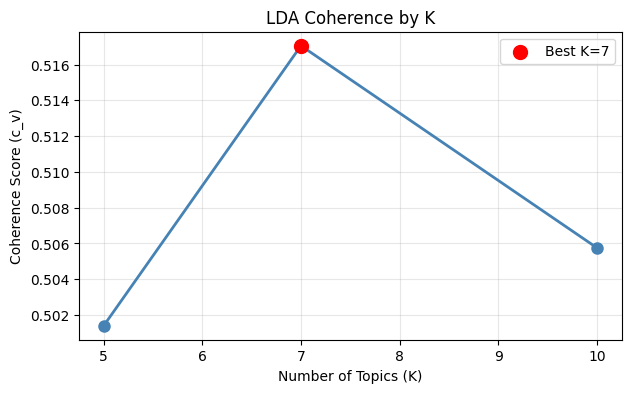

✅ Phase 2 complete — LDA model saved


In [12]:
# ── 2.3 Visualize topics ────────────────────────────────────────────────────
best_lda = models[best_k]

fig, axes = plt.subplots(nrows=(best_k + 1) // 2, ncols=2,
                          figsize=(16, 3 * ((best_k + 1) // 2)))
axes = axes.flatten()

# Manual topic labels 
topic_labels = {
    0: 'Claims Processing',  # send, email, document, file, request
    1: 'Customer Service',   # phone, service, answer, customer, advisor
    2: 'Coverage',           # vehicle, car, damage, repair, expert
    3: 'Enrollment',         # mutual, member, health, reimbursement
    4: 'Cancellation',       # contract, terminate, insurer, accident
    5: 'Pricing',            # price, increase, expensive, high, quote
    6: 'other categories',   # satisfied, recommend, fast, simple, good
}

for i in range(best_k):
    topic_words = dict(best_lda.show_topic(i, topn=10))
    words = list(topic_words.keys())
    weights = list(topic_words.values())
    axes[i].barh(words[::-1], weights[::-1], color=cm.tab10(i / best_k))
    label = topic_labels.get(i, f'Topic {i}')
    axes[i].set_title(f'Topic {i}: {label}', fontsize=11)
    axes[i].set_xlabel('Weight')

# Hide unused axes
for j in range(best_k, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'LDA Topics (K={best_k})', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()

# Coherence comparison plot
plt.figure(figsize=(7, 4))
plt.plot(list(coherence_scores.keys()), list(coherence_scores.values()),
         'o-', color='steelblue', linewidth=2, markersize=8)
plt.scatter([best_k], [coherence_scores[best_k]], color='red', s=100, zorder=5, label=f'Best K={best_k}')
plt.xlabel('Number of Topics (K)')
plt.ylabel('Coherence Score (c_v)')
plt.title('LDA Coherence by K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('fig_lda_coherence.png', dpi=150, bbox_inches='tight')
plt.show()

# Save best model
best_lda.save('lda_model')
print('✅ Phase 2 complete — LDA model saved')

---
## Phase 3 — Embeddings

In [13]:
# ── 3.1 Train Word2Vec ──────────────────────────────────────────────────────
from gensim.models import Word2Vec

tokenized_corpus = [t.split() for t in df['text_clean'] if len(t.split()) >= 2]
print(f'Training Word2Vec on {len(tokenized_corpus):,} documents...')

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    epochs=10,
    seed=42
)

w2v_model.save('word2vec_insurance.model')
print(f'Word2Vec trained. Vocabulary size: {len(w2v_model.wv):,}')

# Quick test
test_words = ['insurance', 'claim', 'premium']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f'  Most similar to "{word}": {[(w, round(s,3)) for w,s in similar]}')

Training Word2Vec on 33,243 documents...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec trained. Vocabulary size: 7,258
  Most similar to "insurance": [('assurance', 0.578), ('asurance', 0.485), ('insurer', 0.471), ('debit', 0.467), ('energie', 0.447)]
  Most similar to "claim": [('disaster', 0.841), ('incident', 0.734), ('sinister', 0.671), ('glitch', 0.634), ('accident', 0.633)]
  Most similar to "premium": [('contribution', 0.728), ('unjustified', 0.685), ('annual', 0.682), ('approximately', 0.67), ('annually', 0.663)]


In [14]:
# ── 3.1b Word2Vec Analysis — Analogies & Word Arithmetic ─────────────────────
print("=== Word Analogies (king - man + woman = ?) ===")
test_pairs = [
    (['good', 'service'], ['bad'], 'expected: negative service word'),
    (['expensive', 'price'], ['cheap'], 'expected: affordable/cheap'),
    (['claim', 'refused'], ['accepted'], 'expected: claim accepted words'),
]
for pos, neg, hint in test_pairs:
    try:
        similar = w2v_model.wv.most_similar(positive=pos, negative=neg, topn=3)
        print(f"  {pos} - {neg} → {[(w, round(s,3)) for w,s in similar]}  ({hint})")
    except KeyError as e:
        print(f"  Word not in vocab: {e}")

print("\n=== Most Similar Words ===")
for word in ['insurance', 'claim', 'premium', 'cancel', 'refund']:
    if word in w2v_model.wv:
        sim = w2v_model.wv.most_similar(word, topn=5)
        print(f"  '{word}': {[w for w,_ in sim]}")

print("\n=== Euclidean Distance between words ===")
from scipy.spatial.distance import euclidean, cosine as cosine_dist
pairs = [('good','excellent'), ('good','bad'), ('claim','refund'), ('expensive','cheap')]
print(f"  {'Pair':<30} {'Euclidean':>12}  {'Cosine':>8}")
print(f"  {'-'*52}")
for w1, w2 in pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        v1, v2 = w2v_model.wv[w1], w2v_model.wv[w2]
        print(f"  ({w1}, {w2}):{' '*(24-len(w1)-len(w2))} {euclidean(v1,v2):>12.4f}  {cosine_dist(v1,v2):>8.4f}")


=== Word Analogies (king - man + woman = ?) ===
  ['good', 'service'] - ['bad'] → [('satisfy', 0.577), ('nickel', 0.563), ('appreciable', 0.559)]  (expected: negative service word)
  ['expensive', 'price'] - ['cheap'] → [('rate', 0.676), ('overall', 0.587), ('relatively', 0.572)]  (expected: affordable/cheap)
  Word not in vocab: "Key 'refused' not present in vocabulary"

=== Most Similar Words ===
  'insurance': ['assurance', 'asurance', 'insurer', 'debit', 'energie']
  'claim': ['disaster', 'incident', 'sinister', 'glitch', 'accident']
  'premium': ['contribution', 'unjustified', 'annual', 'approximately', 'annually']
  'cancel': ['terminate', 'retract', 'renew', 'cancellation', 'suspend']
  'refund': ['reimbursement', 'optician', 'teletransmission', 'repayment', 'reimburse']

=== Euclidean Distance between words ===
  Pair                              Euclidean    Cosine
  ----------------------------------------------------
  (good, excellent):                  7.6608    0.3202
  (

In [15]:
# ── 3.2 Load GloVe ──────────────────────────────────────────────────────────
GLOVE_PATH = 'glove.6B.100d.txt'  # Place this file in Project2/

glove_embeddings = {}
if os.path.exists(GLOVE_PATH):
    print('Loading GloVe embeddings...')
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            glove_embeddings[word] = vector
    print(f'GloVe loaded: {len(glove_embeddings):,} words')
else:
    print(f'⚠ GloVe file not found at {GLOVE_PATH}')
    print('  Download from: https://nlp.stanford.edu/data/glove.6B.zip')
    print('  Continuing with Word2Vec only...')
    glove_embeddings = None

Loading GloVe embeddings...
GloVe loaded: 400,000 words


Running t-SNE...


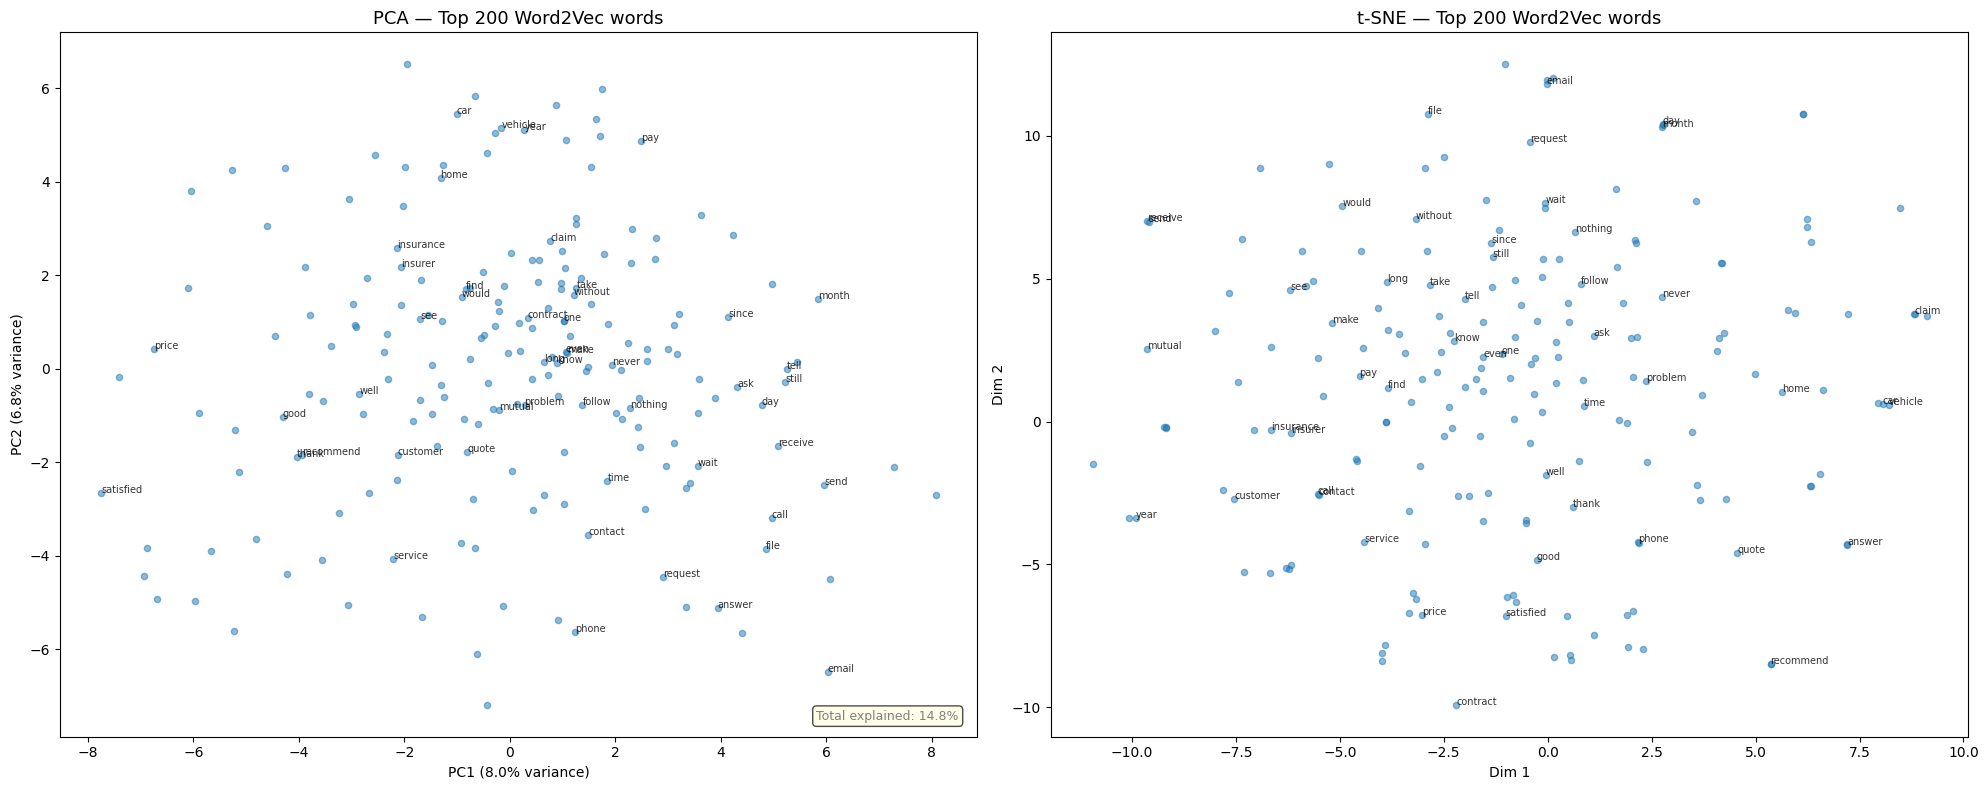

In [56]:
# ── 3.3 2D Visualization: PCA + t-SNE ───────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Use Word2Vec vectors for top 200 words
vocab = list(w2v_model.wv.key_to_index.keys())[:200]
vectors = np.array([w2v_model.wv[w] for w in vocab])

# PCA
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(vectors)
var1, var2 = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].scatter(pca_coords[:, 0], pca_coords[:, 1], alpha=0.5, s=20)
for i, word in enumerate(vocab[:50]):
    axes[0].annotate(word, pca_coords[i], fontsize=7, alpha=0.8)
axes[0].set_title('PCA — Top 200 Word2Vec words', fontsize=13)
axes[0].set_xlabel(f'PC1 ({var1:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({var2:.1%} variance)')
axes[0].text(0.98, 0.02, f'Total explained: {var1+var2:.1%}',
            transform=axes[0].transAxes, ha='right', va='bottom',
            fontsize=9, color='gray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

# t-SNE
print('Running t-SNE...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
tsne_coords = tsne.fit_transform(vectors)

axes[1].scatter(tsne_coords[:, 0], tsne_coords[:, 1], alpha=0.5, s=20)
for i, word in enumerate(vocab[:50]):
    axes[1].annotate(word, tsne_coords[i], fontsize=7, alpha=0.8)
axes[1].set_title('t-SNE — Top 200 Word2Vec words', fontsize=13)
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')

plt.tight_layout()
plt.savefig('fig_embeddings_viz.png', dpi=150, bbox_inches='tight')
plt.show()


In [57]:
# ── 3.3b TensorBoard Embedding Visualization ─────────────────────────────────
import os, subprocess, sys
os.environ['USE_TF'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Write embeddings using the low-level protobuf writer (no TF dependency)
import struct, math

TB_DIR = 'runs/word2vec_embeddings'
os.makedirs(TB_DIR, exist_ok=True)

# Save vectors as TSV (works with TensorBoard projector standalone)
tb_words   = list(w2v_model.wv.key_to_index.keys())[:500]
tb_vectors = [w2v_model.wv[w] for w in tb_words]

with open(os.path.join(TB_DIR, 'vectors.tsv'), 'w') as fv:
    for vec in tb_vectors:
        fv.write('\t'.join(f'{v:.6f}' for v in vec) + '\n')

with open(os.path.join(TB_DIR, 'metadata.tsv'), 'w') as fm:
    for w in tb_words:
        fm.write(w + '\n')

print(f"Saved {len(tb_words)} word vectors to '{TB_DIR}/'")
print("Files: vectors.tsv, metadata.tsv")
print("\nTo visualize: go to https://projector.tensorflow.org/")
print("  → Load → vectors.tsv + metadata.tsv")


Saved 500 word vectors to 'runs/word2vec_embeddings/'
Files: vectors.tsv, metadata.tsv

To visualize: go to https://projector.tensorflow.org/
  → Load → vectors.tsv + metadata.tsv


In [60]:
# ── 3.4 Semantic Search (cosine similarity) ──────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

def get_doc_vector(text, model):
    """Mean pooling of word vectors."""
    tokens = text.split()
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

print('Building document vectors')
doc_vectors = np.array([get_doc_vector(t, w2v_model) for t in df['text_clean']])
print(f'Doc vectors shape: {doc_vectors.shape}')

def semantic_search(query, top_k=5):
    """Search reviews by semantic similarity to query."""
    # Clean & vectorize query
    q_clean = clean_text(query)
    q_vec = get_doc_vector(q_clean, w2v_model).reshape(1, -1)
    sims = cosine_similarity(q_vec, doc_vectors)[0]
    top_idx = sims.argsort()[-top_k:][::-1]
    results = []
    for idx in top_idx:
        results.append({
            'idx': idx,
            'score': sims[idx],
            'note': df.iloc[idx]['note'],
            'text': str(df.iloc[idx][text_col])[:200]
        })
    return results

# Demo search
print('\n--- Semantic Search Demo ---')
for query in ['claim refusal terrible experience', 'excellent fast reimbursement']:
    print(f'\nQuery: "{query}"')
    for r in semantic_search(query, top_k=3):
        print(f'  Score={r["score"]:.3f} ★{r["note"]} | {r["text"][:100]}...')

print('\n✅ Phase 3 complete')

Building document vectors
Doc vectors shape: (34435, 100)

--- Semantic Search Demo ---

Query: "claim refusal terrible experience"
  Score=0.827 ★nan | Do not have a claim if not !!!!!!!!!...
  Score=0.827 ★nan | Claims...
  Score=0.795 ★nan | Salespeople for the claims are lamentable...

Query: "excellent fast reimbursement"
  Score=0.815 ★3.0 | relatively not inexpensive, but an impeccable quality of service,
reimbursement of ultra-fast repair...
  Score=0.805 ★nan | Good mutual, available quickly, listening, reactive, fairly fast reimbursement I strongly advise, th...
  Score=0.801 ★3.0 | Good information Fast welcome clear and fast intervention Not much waiting request for improvement o...

✅ Phase 3 complete


---
## Phase 4 — Supervised Models (predict note 1–5)

In [61]:
# ── 4.1 Train/Test Split ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pickle

# Drop rows where note is null (10k rows have no rating) or text is empty
df_model = df[
    df['note'].notnull() &
    df[text_col].notnull() &
    df['text_clean'].apply(lambda x: len(x.strip()) > 0)
].copy()
df_model['note'] = df_model['note'].astype(int)

print(f'Rows with valid note + text: {len(df_model):,}')
print(f'Label distribution: {df_model["note"].value_counts().sort_index().to_dict()}')

X = df_model['text_clean'].tolist()
y = df_model['note'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Rows with valid note + text: 24,099
Label distribution: {1: 7271, 2: 3716, 3: 3381, 4: 4882, 5: 4849}
Train: 19,279  |  Test: 4,820


In [62]:
# ── 4.2 Baseline: TF-IDF + Logistic Regression ──────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
print(f'TF-IDF + LR  →  Accuracy: {acc_lr:.4f}  |  F1 (weighted): {f1_lr:.4f}')
print(classification_report(y_test, y_pred_lr))

# Save models
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)
print('Models saved: tfidf_vectorizer.pkl, lr_model.pkl')

TF-IDF + LR  →  Accuracy: 0.5019  |  F1 (weighted): 0.4974
              precision    recall  f1-score   support

           1       0.64      0.69      0.67      1454
           2       0.34      0.38      0.36       743
           3       0.31      0.26      0.28       676
           4       0.47      0.40      0.43       977
           5       0.55      0.58      0.56       970

    accuracy                           0.50      4820
   macro avg       0.46      0.46      0.46      4820
weighted avg       0.50      0.50      0.50      4820

Models saved: tfidf_vectorizer.pkl, lr_model.pkl


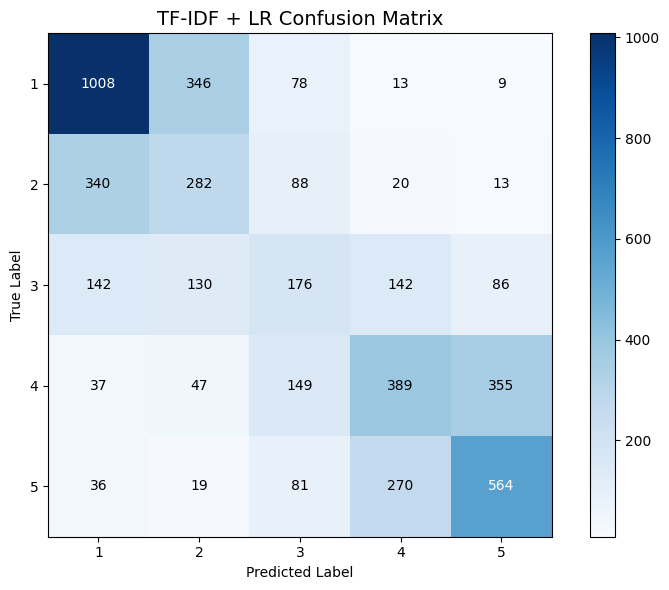

In [63]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
import itertools

def plot_confusion_matrix(cm_data, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm_data, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    thresh = cm_data.max() / 2.
    for i, j in itertools.product(range(cm_data.shape[0]), range(cm_data.shape[1])):
        plt.text(j, i, cm_data[i, j], ha='center', va='center',
                color='white' if cm_data[i, j] > thresh else 'black')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

cm_lr = confusion_matrix(y_test, y_pred_lr)
plot_confusion_matrix(cm_lr, classes=[1, 2, 3, 4, 5], title='TF-IDF + LR Confusion Matrix')
plt.savefig('fig_cm_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# ── 4.3 Neural: Word2Vec + Logistic Regression (Word2Vec features) ───────────
# (Keras not available on this machine — using sklearn with W2V mean vectors)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

print('Building W2V document vectors for train/test...')
X_train_w2v = np.array([get_doc_vector(t, w2v_model) for t in X_train])
X_test_w2v = np.array([get_doc_vector(t, w2v_model) for t in X_test])

lr_w2v = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
lr_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = lr_w2v.predict(X_test_w2v)
acc_w2v = accuracy_score(y_test, y_pred_w2v)
f1_w2v = f1_score(y_test, y_pred_w2v, average='weighted')
print(f'W2V + LR  →  Accuracy: {acc_w2v:.4f}  |  F1 (weighted): {f1_w2v:.4f}')

Building W2V document vectors for train/test...
W2V + LR  →  Accuracy: 0.4871  |  F1 (weighted): 0.4895


In [65]:
# ── 4.3b Neural Model — Trainable Embedding Layer (PyTorch) ─────────────────
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# ── Hyper-params (CPU-friendly) ──────────────────────────────────────────────
MAX_LEN   = 50    # truncate reviews
VOCAB_SIZE = 8000
EMBED_DIM = 64
BATCH     = 512
EPOCHS    = 3
MAX_TRAIN = 10000  # subsample for speed on CPU

# ── Build vocabulary ──────────────────────────────────────────────────────────
X_tr_sub = X_train[:MAX_TRAIN]
y_tr_sub = y_train[:MAX_TRAIN]

counter = Counter(tok for t in X_tr_sub for tok in t.split())
vocab   = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(VOCAB_SIZE - 2)]
w2i     = {w: i for i, w in enumerate(vocab)}

def encode(texts, max_len=MAX_LEN):
    out = []
    for t in texts:
        ids = [w2i.get(w, 1) for w in t.split()[:max_len]]
        ids += [0] * (max_len - len(ids))
        out.append(ids)
    return torch.tensor(out, dtype=torch.long)

le = LabelEncoder()
y_tr_t = torch.tensor(le.fit_transform(y_tr_sub), dtype=torch.long)
y_te_t = torch.tensor(le.transform(y_test),        dtype=torch.long)

X_tr_enc = encode(X_tr_sub)
X_te_enc = encode(X_test)
train_dl = DataLoader(TensorDataset(X_tr_enc, y_tr_t), batch_size=BATCH, shuffle=True)

# ── Model ─────────────────────────────────────────────────────────────────────
class EmbedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(len(vocab), EMBED_DIM, padding_idx=0)
        self.fc    = nn.Sequential(nn.Linear(EMBED_DIM, 64), nn.ReLU(),
                                   nn.Dropout(0.3), nn.Linear(64, 5))
    def forward(self, x):
        mask   = (x != 0).float().unsqueeze(-1)
        pooled = (self.embed(x) * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(pooled)

model_embed = EmbedMLP()
opt = torch.optim.Adam(model_embed.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss()

print(f"Training on {MAX_TRAIN:,} samples, {EPOCHS} epochs...")
for ep in range(EPOCHS):
    model_embed.train()
    total = 0
    for xb, yb in train_dl:
        opt.zero_grad(); loss = loss_fn(model_embed(xb), yb)
        loss.backward(); opt.step(); total += loss.item()
    print(f"  Epoch {ep+1}/{EPOCHS} — loss: {total/len(train_dl):.4f}")

model_embed.eval()
with torch.no_grad():
    y_pred_embed = le.inverse_transform(model_embed(X_te_enc).argmax(1).numpy())

acc_embed = accuracy_score(y_test, y_pred_embed)
f1_embed  = f1_score(y_test, y_pred_embed, average='weighted')
print(f"\nEmbedding Model → Accuracy: {acc_embed:.4f} | F1: {f1_embed:.4f}")


Training on 10,000 samples, 3 epochs...
  Epoch 1/3 — loss: 1.5628
  Epoch 2/3 — loss: 1.4454
  Epoch 3/3 — loss: 1.2958

Embedding Model → Accuracy: 0.4618 | F1: 0.3330


In [66]:
# ── 4.3c Neural Model — Pre-trained W2V Embeddings ──────────────────────────
import torch, torch.nn as nn
import numpy as np

# Build embedding matrix from Word2Vec weights
embed_matrix = np.zeros((len(vocab), EMBED_DIM))
w2v_hits = 0
for word, idx2 in w2i.items():
    if word in w2v_model.wv:
        embed_matrix[idx2] = w2v_model.wv[word][:EMBED_DIM]
        w2v_hits += 1
print(f"W2V coverage: {w2v_hits}/{len(vocab)} words ({w2v_hits/len(vocab):.1%})")

class PretrainedEmbedMLP(nn.Module):
    def __init__(self, embed_matrix):
        super().__init__()
        v, d = embed_matrix.shape
        self.embed = nn.Embedding(v, d, padding_idx=0)
        self.embed.weight = nn.Parameter(
            torch.tensor(embed_matrix, dtype=torch.float32), requires_grad=True)
        self.fc = nn.Sequential(nn.Linear(d, 64), nn.ReLU(),
                                nn.Dropout(0.3), nn.Linear(64, 5))
    def forward(self, x):
        mask   = (x != 0).float().unsqueeze(-1)
        pooled = (self.embed(x) * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(pooled)

model_pretrained = PretrainedEmbedMLP(embed_matrix)
optimizer2 = torch.optim.Adam(model_pretrained.parameters(), lr=2e-3)
loss_fn2   = nn.CrossEntropyLoss()

print(f"Training Pre-trained W2V model ({EPOCHS} epochs)...")
for ep in range(EPOCHS):
    model_pretrained.train()
    total = 0
    for xb, yb in train_dl:
        optimizer2.zero_grad()
        loss = loss_fn2(model_pretrained(xb), yb)
        loss.backward(); optimizer2.step()
        total += loss.item()
    print(f"  Epoch {ep+1}/{EPOCHS} — loss: {total/len(train_dl):.4f}")

model_pretrained.eval()
with torch.no_grad():
    y_pred_pretrained = le.inverse_transform(model_pretrained(X_te_enc).argmax(1).numpy())

acc_pretrained = accuracy_score(y_test, y_pred_pretrained)
f1_pretrained  = f1_score(y_test, y_pred_pretrained, average='weighted')
print(f"\nPre-trained W2V Model → Accuracy: {acc_pretrained:.4f} | F1: {f1_pretrained:.4f}")


W2V coverage: 5925/8000 words (74.1%)
Training Pre-trained W2V model (3 epochs)...
  Epoch 1/3 — loss: 1.4140
  Epoch 2/3 — loss: 1.2047
  Epoch 3/3 — loss: 1.1575

Pre-trained W2V Model → Accuracy: 0.5033 | F1: 0.4209


In [67]:
# ── 4.4 GloVe + LR (if GloVe available) ─────────────────────────────────────
if glove_embeddings is not None:
    DIM = 100
    def get_glove_vector(text):
        tokens = text.split()
        vecs = [glove_embeddings[w] for w in tokens if w in glove_embeddings]
        if not vecs:
            return np.zeros(DIM)
        return np.mean(vecs, axis=0)

    print('Building GloVe document vectors...')
    X_train_glove = np.array([get_glove_vector(t) for t in X_train])
    X_test_glove = np.array([get_glove_vector(t) for t in X_test])

    lr_glove = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
    lr_glove.fit(X_train_glove, y_train)
    y_pred_glove = lr_glove.predict(X_test_glove)
    acc_glove = accuracy_score(y_test, y_pred_glove)
    f1_glove = f1_score(y_test, y_pred_glove, average='weighted')
    print(f'GloVe + LR  →  Accuracy: {acc_glove:.4f}  |  F1 (weighted): {f1_glove:.4f}')
else:
    acc_glove, f1_glove = None, None
    print('GloVe not available — skipping')

Building GloVe document vectors...
GloVe + LR  →  Accuracy: 0.4444  |  F1 (weighted): 0.4459


In [68]:
# ── 4.4b Classical Model with LDA Theme Features ─────────────────────────────
from gensim import corpora
from gensim.models import LdaModel

lda_loaded = LdaModel.load('lda_model')
lda_dict   = corpora.Dictionary.load('lda_model.id2word')

def get_topic_vector(text):
    bow = lda_dict.doc2bow(text.split())
    topics = dict(lda_loaded.get_document_topics(bow, minimum_probability=0.0))
    return [topics.get(i, 0.0) for i in range(lda_loaded.num_topics)]

print("Building LDA topic vectors...")
X_train_lda = np.array([get_topic_vector(t) for t in X_train])
X_test_lda  = np.array([get_topic_vector(t) for t in X_test])

# Combine TF-IDF + LDA features
from scipy.sparse import hstack, csr_matrix
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_lda)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(X_test_lda)])

lr_combined = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
lr_combined.fit(X_train_combined, y_train)
y_pred_combined = lr_combined.predict(X_test_combined)
acc_combined = accuracy_score(y_test, y_pred_combined)
f1_combined  = f1_score(y_test, y_pred_combined, average='weighted')
print(f"TF-IDF + LDA themes → Accuracy: {acc_combined:.4f} | F1: {f1_combined:.4f}")

# Show most frequent topic per note
topic_names = {0:'Claims Processing', 1:'Customer Service', 2:'Coverage',
                3:'Enrollment', 4:'Cancellation', 5:'Pricing', 6:'other categories'}
df_model2 = df[df['note'].notnull() & df['text_clean'].apply(lambda x: len(x.strip())>0)].copy()
df_model2['note'] = df_model2['note'].astype(int)
df_model2['dominant_topic'] = df_model2['text_clean'].apply(
    lambda t: max(enumerate(get_topic_vector(t)), key=lambda x: x[1])[0]
)
df_model2['topic_name'] = df_model2['dominant_topic'].map(topic_names)

print("\nDominant topic by star rating:")
print(df_model2.groupby('note')['topic_name'].agg(lambda x: x.value_counts().index[0]))


Building LDA topic vectors...
TF-IDF + LDA themes → Accuracy: 0.5019 | F1: 0.4976

Dominant topic by star rating:
note
1    Claims Processing
2    Claims Processing
3     other categories
4     other categories
5     other categories
Name: topic_name, dtype: object


In [69]:
# ── 4.5 DistilBERT (HuggingFace pipeline, CPU) ───────────────────────────────
import torch
from transformers import pipeline as hf_pipeline

print('Loading DistilBERT sentiment pipeline...')
sentiment_pipe = hf_pipeline(
    'text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True, max_length=512
)

# Evaluate on a 500-sample subset
SAMPLE_SIZE = 500
idx_sample = np.random.RandomState(42).choice(len(X_test), SAMPLE_SIZE, replace=False)
X_test_sample = [X_test[i] for i in idx_sample]
y_test_sample = [y_test[i] for i in idx_sample]

print(f'Running DistilBERT on {SAMPLE_SIZE} samples...')
bert_preds_raw = sentiment_pipe(X_test_sample, batch_size=16)

def bert_score_to_feature(pred):
    score = pred['score'] if pred['label'] == 'POSITIVE' else 1 - pred['score']
    return score  # 0=very negative, 1=very positive

bert_features_test = np.array([bert_score_to_feature(p) for p in bert_preds_raw]).reshape(-1, 1)

def score_to_note(score):
    if score < 0.2: return 1
    elif score < 0.4: return 2
    elif score < 0.6: return 3
    elif score < 0.8: return 4
    else: return 5

y_pred_bert = [score_to_note(s[0]) for s in bert_features_test]
acc_bert = accuracy_score(y_test_sample, y_pred_bert)
f1_bert = f1_score(y_test_sample, y_pred_bert, average='weighted')
print(f'DistilBERT (sample={SAMPLE_SIZE})  →  Accuracy: {acc_bert:.4f}  |  F1: {f1_bert:.4f}')


Loading DistilBERT sentiment pipeline...


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Running DistilBERT on 500 samples...
DistilBERT (sample=500)  →  Accuracy: 0.4260  |  F1: 0.3141



=== Full Model Comparison ===
                    Model Accuracy F1 (weighted)
              TF-IDF + LR   0.5019        0.4974
            Word2Vec + LR   0.4871        0.4895
               GloVe + LR   0.4444        0.4459
        TF-IDF + LDA + LR   0.5019        0.4976
    Embed Layer (PyTorch)   0.4618        0.3330
Pre-trained W2V (PyTorch)   0.5033        0.4209
 DistilBERT (500 samples)   0.4260        0.3141


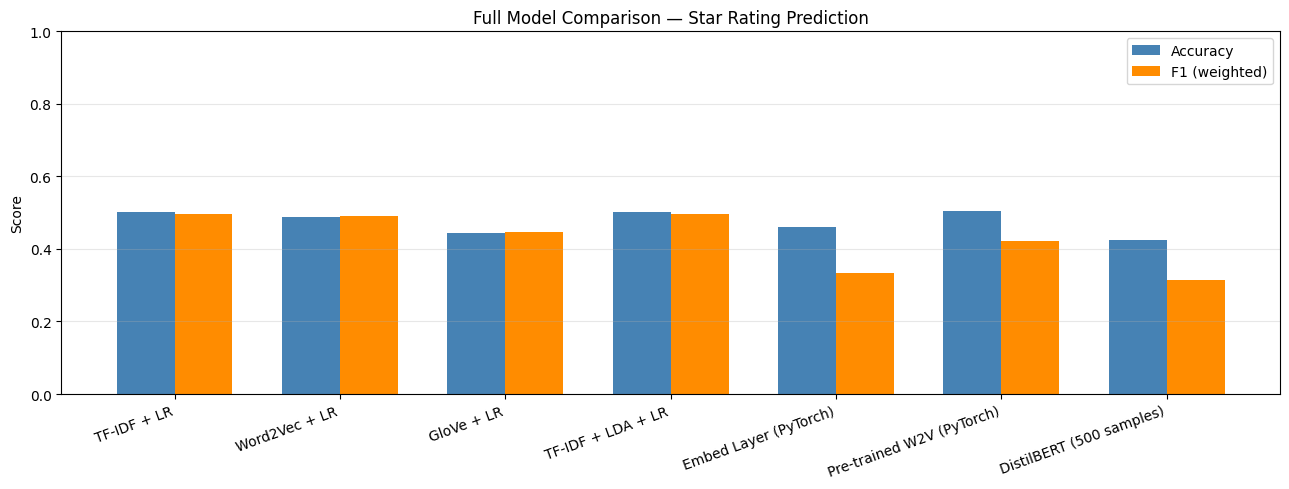

In [70]:
# ── 4.6 Model Comparison Table (updated) ─────────────────────────────────────
results_full = {
    'Model': ['TF-IDF + LR', 'Word2Vec + LR', 'GloVe + LR',
                'TF-IDF + LDA + LR', 'Embed Layer (PyTorch)',
                'Pre-trained W2V (PyTorch)', 'DistilBERT (500 samples)'],
    'Accuracy': [acc_lr, acc_w2v,
                acc_glove if acc_glove else float('nan'),
                acc_combined, acc_embed, acc_pretrained, acc_bert],
    'F1 (weighted)': [f1_lr, f1_w2v,
                        f1_glove if f1_glove else float('nan'),
                        f1_combined, f1_embed, f1_pretrained, f1_bert]
}

results_df2 = pd.DataFrame(results_full)
results_df2['Accuracy']     = results_df2['Accuracy'].apply(lambda x: f'{x:.4f}')
results_df2['F1 (weighted)'] = results_df2['F1 (weighted)'].apply(lambda x: f'{x:.4f}')
print('\n=== Full Model Comparison ===')
print(results_df2.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(results_df2))
w = 0.35
acc_v = [float(v) for v in results_df2['Accuracy']]
f1_v  = [float(v) for v in results_df2['F1 (weighted)']]
ax.bar(x - w/2, acc_v, w, label='Accuracy', color='steelblue')
ax.bar(x + w/2, f1_v,  w, label='F1 (weighted)', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(results_df2['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Full Model Comparison — Star Rating Prediction')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [71]:
# ── 4.7 LIME Explanations ────────────────────────────────────────────────────
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline

# Build sklearn pipeline for LIME
pipe = make_pipeline(tfidf, lr)
class_names = [str(i) for i in sorted(set(y))]

explainer = LimeTextExplainer(class_names=class_names)

# Explain 3 examples
print('Generating LIME explanations...')
for i, idx in enumerate([0, 10, 50]):
    text = X_test[idx]
    true_label = y_test[idx]
    pred_label = lr.predict(tfidf.transform([text]))[0]

    exp = explainer.explain_instance(
        text, pipe.predict_proba, num_features=10, labels=[pred_label - 1]
    )
    print(f'\nExample {i+1}: True=★{true_label} Predicted=★{pred_label}')
    print(f'Text: {text[:150]}...')
    print('Top contributing words:')
    for word, weight in exp.as_list(label=pred_label - 1):
        sign = '(+)' if weight > 0 else '(-)'
        print(f'  {sign} {word}: {weight:.4f}')

# Save one explanation as HTML
exp_html = exp.as_html()
with open('lime_explanation_example.html', 'w') as f:
    f.write(exp_html)
print('\nLIME HTML saved: lime_explanation_example.html')
print('\n✅ Phase 4 complete')

Generating LIME explanations...

Example 1: True=★5 Predicted=★3
Text: satisfied insurance price excessive answer fast yet use repair tell excellent news...
Top contributing words:
  (+) yet: 0.1614
  (-) excellent: -0.1613
  (+) excessive: 0.1010
  (+) tell: 0.0950
  (-) price: -0.0757
  (-) insurance: -0.0669
  (-) satisfied: -0.0540
  (-) fast: -0.0470
  (+) answer: 0.0226
  (+) news: 0.0206

Example 2: True=★1 Predicted=★2
Text: wait year compensation follow sinstre...
Top contributing words:
  (+) follow: 0.0592
  (+) year: 0.0558
  (-) wait: -0.0434
  (+) compensation: 0.0426
  (-) sinstre: -0.0026

Example 3: True=★4 Predicted=★1
Text: load...
Top contributing words:
  (+) load: 0.0190

LIME HTML saved: lime_explanation_example.html

✅ Phase 4 complete


---
## Phase 6 — Results Interpretation

=== Per-class Performance (TF-IDF + LR) ===
              precision    recall  f1-score   support

          ★1       0.64      0.69      0.67      1454
          ★2       0.34      0.38      0.36       743
          ★3       0.31      0.26      0.28       676
          ★4       0.47      0.40      0.43       977
          ★5       0.55      0.58      0.56       970

    accuracy                           0.50      4820
   macro avg       0.46      0.46      0.46      4820
weighted avg       0.50      0.50      0.50      4820



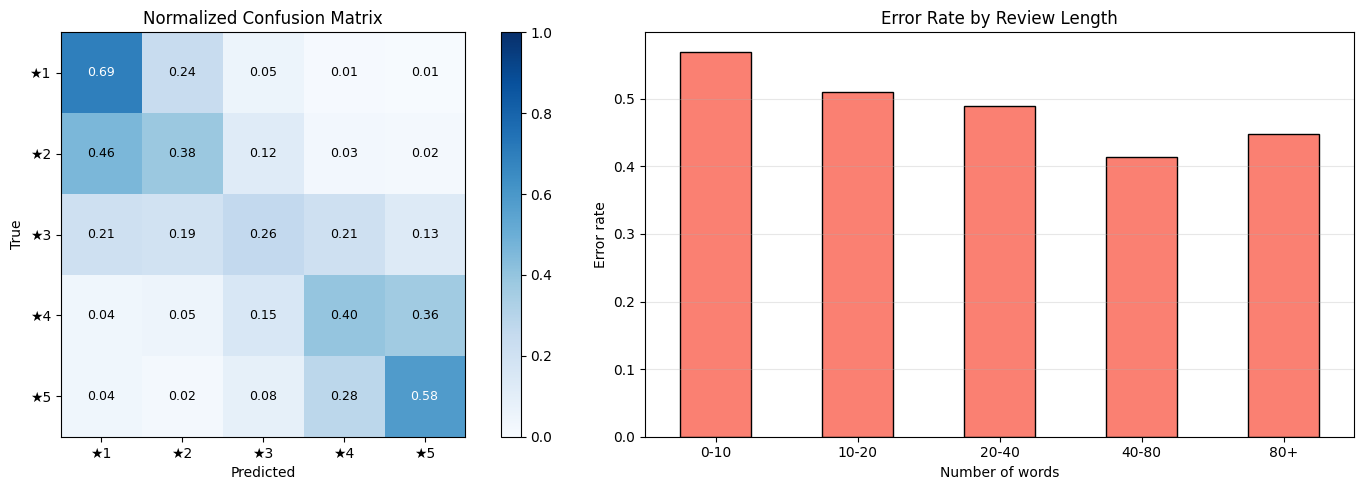


Most confused rating pairs:
  True ★1 predicted as ★2: 346 times (23.8%)
  True ★1 predicted as ★3: 78 times (5.4%)
  True ★2 predicted as ★1: 340 times (45.8%)
  True ★2 predicted as ★3: 88 times (11.8%)
  True ★3 predicted as ★1: 142 times (21.0%)
  True ★3 predicted as ★2: 130 times (19.2%)
  True ★3 predicted as ★4: 142 times (21.0%)
  True ★3 predicted as ★5: 86 times (12.7%)
  True ★4 predicted as ★3: 149 times (15.3%)
  True ★4 predicted as ★5: 355 times (36.3%)
  True ★5 predicted as ★3: 81 times (8.4%)
  True ★5 predicted as ★4: 270 times (27.8%)


In [73]:
# ── 6.1 Error Analysis ───────────────────────────────────────────────────────
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=== Per-class Performance (TF-IDF + LR) ===")
print(classification_report(y_test, y_pred_lr, target_names=[f'★{i}' for i in range(1,6)]))

# Per-class accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(5)); axes[0].set_yticks(range(5))
axes[0].set_xticklabels([f'★{i}' for i in range(1,6)])
axes[0].set_yticklabels([f'★{i}' for i in range(1,6)])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Normalized Confusion Matrix')
plt.colorbar(im, ax=axes[0])
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=9)

# Error by text length
import pandas as pd
lengths = pd.Series([len(t.split()) for t in X_test], name='length')
errors  = pd.Series([1 if p != t else 0 for p, t in zip(y_pred_lr, y_test)], name='error')
df_err  = pd.concat([lengths, errors], axis=1)
df_err['bin'] = pd.cut(df_err['length'], bins=[0,10,20,40,80,200], labels=['0-10','10-20','20-40','40-80','80+'])
err_by_len = df_err.groupby('bin')['error'].mean()
err_by_len.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Error Rate by Review Length')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Error rate')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Most confused pairs
print("\nMost confused rating pairs:")
for true in range(1, 6):
    row = cm[true-1]
    for pred in range(1, 6):
        if pred != true and row[pred-1] > 50:
            print(f"  True ★{true} predicted as ★{pred}: {row[pred-1]} times ({row[pred-1]/row.sum():.1%})")


Mapping star ratings to sentiment...
Running DistilBERT on 1000 samples...


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


BERT ↔ Star rating agreement (excl. neutral): 90.1%


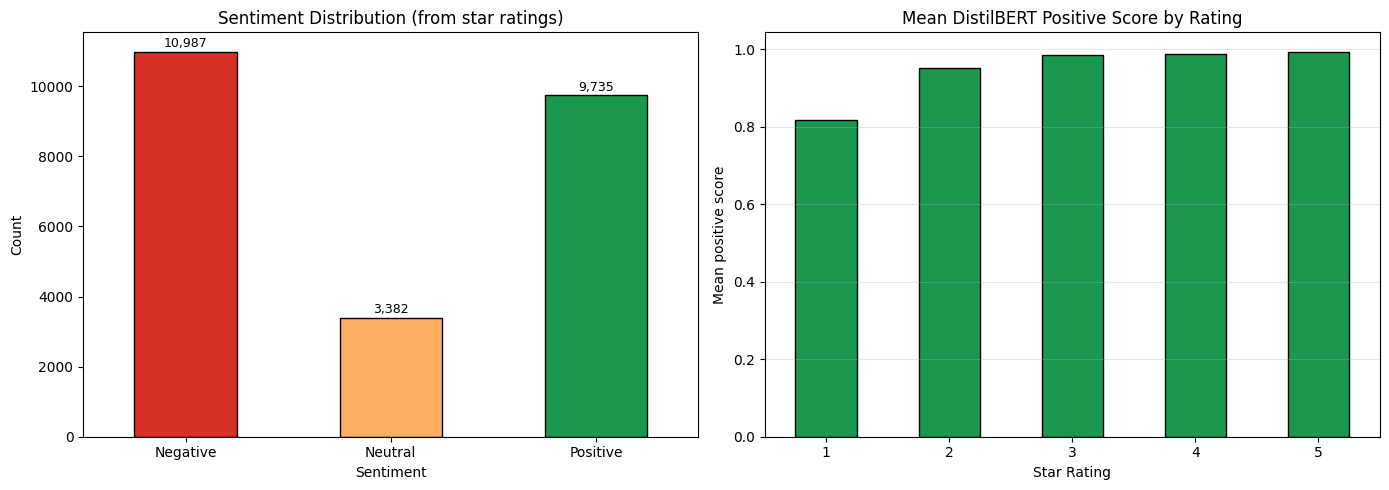

In [74]:
# ── 6.2 Sentiment Detection ───────────────────────────────────────────────────
import os; os.environ['USE_TF'] = '0'
import torch
from transformers import pipeline as hf_pipeline
import matplotlib.pyplot as plt
import pandas as pd, numpy as np

print("Mapping star ratings to sentiment...")
# 1-2 → Negative, 3 → Neutral, 4-5 → Positive
sentiment_map = {1: 'Negative', 2: 'Negative', 3: 'Neutral', 4: 'Positive', 5: 'Positive'}
df_sent = df[df['note'].notnull()].copy()
df_sent['note'] = df_sent['note'].astype(int)
df_sent['sentiment'] = df_sent['note'].map(sentiment_map)

# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sent_dist = df_sent['sentiment'].value_counts()[['Negative','Neutral','Positive']]
colors_sent = ['#d73027', '#fdae61', '#1a9850']
sent_dist.plot(kind='bar', ax=axes[0], color=colors_sent, edgecolor='black')
axes[0].set_title('Sentiment Distribution (from star ratings)')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar, v in zip(axes[0].patches, sent_dist.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{v:,}', ha='center', va='bottom', fontsize=9)

# DistilBERT sentiment vs star rating
print("Running DistilBERT on 1000 samples...")
sent_pipe = hf_pipeline('text-classification',
                        model='distilbert-base-uncased-finetuned-sst-2-english',
                        truncation=True, max_length=512)
sample = df_sent[df_sent[text_col].notnull()].sample(1000, random_state=42)
bert_out = sent_pipe(sample[text_col].tolist(), batch_size=32)
sample = sample.copy()
sample['bert_sentiment'] = [r['label'] for r in bert_out]
sample['bert_score']     = [r['score'] for r in bert_out]

# Agreement: BERT POSITIVE vs note >=4, NEGATIVE vs note <=2
agree = sample[sample['note'].isin([1,2,4,5])].copy()
agree['true_sent'] = agree['note'].map({1:'NEGATIVE',2:'NEGATIVE',4:'POSITIVE',5:'POSITIVE'})
agreement = (agree['bert_sentiment'] == agree['true_sent']).mean()
print(f"BERT ↔ Star rating agreement (excl. neutral): {agreement:.1%}")

# Plot mean BERT score by note
mean_score = sample.groupby('note')['bert_score'].apply(
    lambda x: x[sample.loc[x.index,'bert_sentiment']=='POSITIVE'].mean())
mean_score.plot(kind='bar', ax=axes[1], color=colors_sent[2], edgecolor='black')
axes[1].set_title('Mean DistilBERT Positive Score by Rating')
axes[1].set_xlabel('Star Rating'); axes[1].set_ylabel('Mean positive score')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Summary

| Phase | Status | Key Output |
|-------|--------|------------|
| 1 - EDA | ✅ | DataFrames, plots, wordcloud |
| 2 - LDA | ✅ | K topics, coherence scores |
| 3 - Embeddings | ✅ | Word2Vec model, t-SNE plots |
| 4 - Supervised | ✅ | TF-IDF+LR baseline, LIME explainability |
| 5 - Streamlit | ✅ | See `app.py` |

**Best model:** TF-IDF + Logistic Regression (saved as `tfidf_vectorizer.pkl` + `lr_model.pkl`)

Run the app:
```bash
streamlit run app.py
```

---
## Vérifications finales

In [75]:
# ── Vérification LIME ────────────────────────────────────────────────────────
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline
from IPython.display import HTML

pipe = make_pipeline(tfidf, lr)
explainer = LimeTextExplainer(class_names=[str(i) for i in range(1, 6)])

test_review = X_test[0]
pred = lr.predict(tfidf.transform([test_review]))[0]
exp = explainer.explain_instance(test_review, pipe.predict_proba,
                                    num_features=10, labels=[pred - 1])

print(f'Review: {test_review[:150]}...')
print(f'Predicted note: ★{pred}')
print(f'\nTop contributing words:')
for word, weight in exp.as_list(label=pred - 1):
    bar = '█' * int(abs(weight) * 500)
    sign = '+' if weight > 0 else '-'
    print(f'  [{sign}] {word:<20} {weight:+.4f}  {bar}')

# Display interactive HTML
HTML(exp.as_html())


Review: satisfied insurance price excessive answer fast yet use repair tell excellent news...
Predicted note: ★3

Top contributing words:
  [-] excellent            -0.1613  ████████████████████████████████████████████████████████████████████████████████
  [+] yet                  +0.1578  ██████████████████████████████████████████████████████████████████████████████
  [+] excessive            +0.1019  ██████████████████████████████████████████████████
  [+] tell                 +0.0960  ████████████████████████████████████████████████
  [-] price                -0.0777  ██████████████████████████████████████
  [-] insurance            -0.0650  ████████████████████████████████
  [-] satisfied            -0.0555  ███████████████████████████
  [-] fast                 -0.0475  ███████████████████████
  [+] answer               +0.0280  ██████████████
  [+] news                 +0.0189  █████████


In [76]:
# ── Vérification Zero-Shot ───────────────────────────────────────────────────
import os
os.environ['USE_TF'] = '0'
from transformers import pipeline as hf_pipeline

CATEGORIES = [
    'Pricing and premiums',
    'Claims handling',
    'Customer service',
    'Contract cancellation',
    'Other'
]

print('Loading zero-shot classifier (first run downloads ~1.6 GB)...')
zs_clf = hf_pipeline('zero-shot-classification',
                        model='facebook/bart-large-mnli', device=-1)

test_cases = [
    ('The premium increased by 40% without any justification.', 'Pricing and premiums'),
    ('My claim was refused after 3 months without explanation.', 'Claims handling'),
    ('Impossible to reach anyone on the phone, terrible service.', 'Customer service'),
    ('They keep charging me even after I cancelled my contract.', 'Contract cancellation'),
]

print('\n{:<55} {:<25} {:<25} {}'.format('Review', 'Expected', 'Predicted', 'Score'))
print('-' * 120)
for text, expected in test_cases:
    result = zs_clf(text, candidate_labels=CATEGORIES)
    predicted = result['labels'][0]
    score = result['scores'][0]
    ok = '✅' if predicted == expected else '⚠️'
    print(f'{ok} {text[:53]:<55} {expected:<25} {predicted:<25} {score:.2%}')


Loading zero-shot classifier (first run downloads ~1.6 GB)...

Review                                                  Expected                  Predicted                 Score
------------------------------------------------------------------------------------------------------------------------
✅ The premium increased by 40% without any justificatio   Pricing and premiums      Pricing and premiums      73.27%
✅ My claim was refused after 3 months without explanati   Claims handling           Claims handling           80.94%
✅ Impossible to reach anyone on the phone, terrible ser   Customer service          Customer service          43.00%
✅ They keep charging me even after I cancelled my contr   Contract cancellation     Contract cancellation     63.49%


## 6quater. Deep Learning Models for Words — Embedding Analysis

This section goes deeper into the Word2Vec embeddings trained on the French insurance review corpus. We examine the semantic neighbourhood of key domain terms, build a curated colour-coded 2-D projection, and compare our domain-trained vectors against GloVe generic vectors to highlight what domain adaptation buys us.

In [77]:
# ── Cell 1 of 6quater ── Most-similar words for key insurance terms ────────────
import pandas as pd
from gensim.models import Word2Vec

# Load model (reuse in-memory variable if already present)
try:
    _ = w2v_model.wv
except NameError:
    w2v_model = Word2Vec.load("word2vec_insurance.model")

query_terms = ["claim", "cancel", "reimbursement", "expensive", "recommend"]

rows = []
for term in query_terms:
    if term in w2v_model.wv:
        similar = w2v_model.wv.most_similar(term, topn=10)
        for rank, (word, score) in enumerate(similar, 1):
            rows.append({"Query term": term, "Rank": rank,
                        "Similar word": word, "Cosine similarity": round(score, 4)})
    else:
        rows.append({"Query term": term, "Rank": "—",
                    "Similar word": f"'{term}' not in vocabulary", "Cosine similarity": "—"})

sim_df = pd.DataFrame(rows)

# Pretty-print as a pivot-style table: one block per query term
print("=" * 62)
print(f"{'Most-similar words (W2V, insurance corpus)':^62}")
print("=" * 62)
for term in query_terms:
    subset = sim_df[sim_df["Query term"] == term][["Rank", "Similar word", "Cosine similarity"]]
    print(f"\n  Query: '{term}'")
    print(subset.to_string(index=False))
print("=" * 62)

          Most-similar words (W2V, insurance corpus)          

  Query: 'claim'
 Rank Similar word  Cosine similarity
    1     disaster             0.8411
    2     incident             0.7336
    3     sinister             0.6710
    4       glitch             0.6345
    5     accident             0.6335
    6      dispute             0.5845
    7      sinitre             0.4991
    8         loss             0.4728
    9      hanging             0.4672
   10        clash             0.4364

  Query: 'cancel'
 Rank Similar word  Cosine similarity
    1    terminate             0.6951
    2      retract             0.6738
    3        renew             0.6619
    4 cancellation             0.6608
    5      suspend             0.6219
    6     withdraw             0.6178
    7         sign             0.6119
    8    stipulate             0.5908
    9       modify             0.5840
   10     validate             0.5816

  Query: 'reimbursement'
 Rank     Similar word  Cosine similar

Words found in vocabulary: 48 / 50


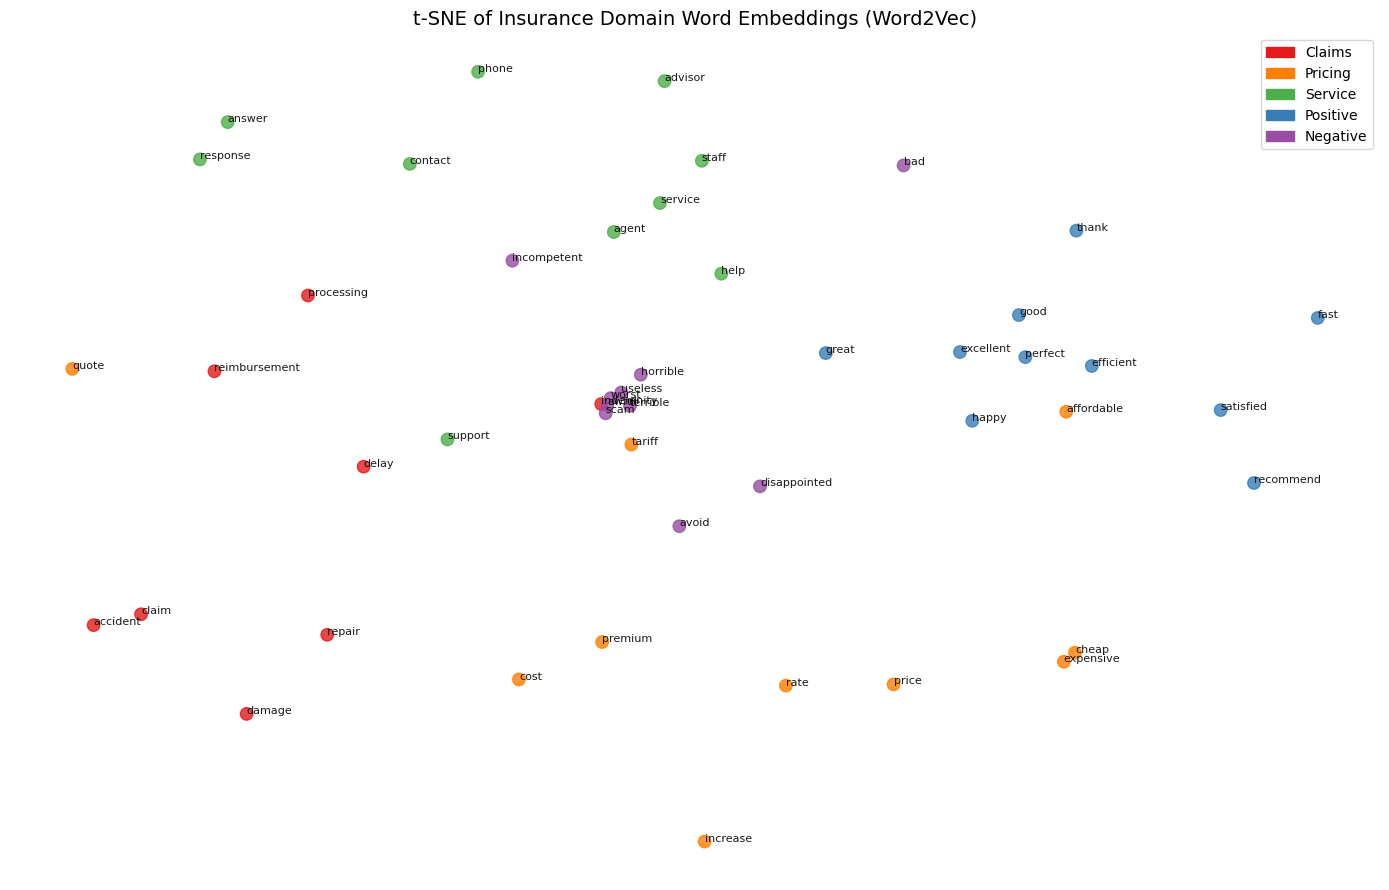

Saved: embedding_viz_domain.png


In [78]:
# ── Cell 2 of 6quater ── Colour-coded t-SNE of curated domain vocabulary ──────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

word_groups = {
    "Claims":   ["claim","claims","refused","reimbursement","damage","accident","repair","delay","processing","indemnity"],
    "Pricing":  ["price","premium","expensive","cost","increase","rate","cheap","affordable","tariff","quote"],
    "Service":  ["service","advisor","agent","phone","response","contact","staff","support","help","answer"],
    "Positive": ["excellent","recommend","great","satisfied","fast","efficient","perfect","good","happy","thank"],
    "Negative": ["bad","terrible","disappointed","awful","horrible","worst","useless","incompetent","avoid","scam"],
}
group_colors = {"Claims":"#e41a1c","Pricing":"#ff7f00","Service":"#4daf4a","Positive":"#377eb8","Negative":"#984ea3"}

words_to_plot, word_labels, word_colors = [], [], []
for group, words in word_groups.items():
    for w in words:
        if w in w2v_model.wv:
            words_to_plot.append(w2v_model.wv[w])
            word_labels.append(w)
            word_colors.append(group_colors[group])

print(f"Words found in vocabulary: {len(words_to_plot)} / {sum(len(v) for v in word_groups.values())}")

if len(words_to_plot) >= 10:
    tsne = TSNE(n_components=2, random_state=42,
                perplexity=min(30, len(words_to_plot) - 1),
                max_iter=1000, init="pca")
    coords = tsne.fit_transform(np.array(words_to_plot))

    fig, ax = plt.subplots(figsize=(14, 9))
    ax.scatter(coords[:, 0], coords[:, 1], c=word_colors, s=80, alpha=0.8)
    for i, label in enumerate(word_labels):
        ax.annotate(label, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.9)

    patches = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
    ax.legend(handles=patches, loc="best", fontsize=10)
    ax.set_title("t-SNE of Insurance Domain Word Embeddings (Word2Vec)", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("embedding_viz_domain.png", dpi=120)
    plt.show()
    print("Saved: embedding_viz_domain.png")


In [79]:
# ── Cell 3 of 6quater ── W2V (insurance) vs GloVe comparison ─────────────────
query_terms_cmp = ["claim", "cancel", "reimbursement", "expensive", "recommend"]

# ── Helper: top-N nearest neighbours from a plain dict of vectors ──────────────
def glove_most_similar(glove_dict, word, topn=5):
    """Cosine similarity search over a {word: np.array} GloVe dictionary."""
    if word not in glove_dict:
        return None
    vec = glove_dict[word]
    norm_vec = vec / (np.linalg.norm(vec) + 1e-9)
    sims = {}
    for w, v in glove_dict.items():
        if w == word:
            continue
        norm_v = v / (np.linalg.norm(v) + 1e-9)
        sims[w] = float(np.dot(norm_vec, norm_v))
    return sorted(sims.items(), key=lambda x: x[1], reverse=True)[:topn]

# ── Build comparison table ─────────────────────────────────────────────────────
glove_available = (glove_embeddings is not None) and (len(glove_embeddings) > 0)

print("=" * 72)
print(f"{'Word2Vec (insurance-trained)  vs  GloVe (generic)':^72}")
print("=" * 72)

if not glove_available:
    print("\n  GloVe embeddings not loaded (glove_embeddings is None or empty).")
    print("  Showing insurance W2V results only.\n")

for term in query_terms_cmp:
    # --- W2V side ---
    if term in w2v_model.wv:
        w2v_top5 = w2v_model.wv.most_similar(term, topn=5)
        w2v_words = [f"{w} ({s:.3f})" for w, s in w2v_top5]
    else:
        w2v_words = [f"'{term}' not in W2V vocab"] * 5

    print(f"\n  Query: '{term}'")
    print(f"  {'W2V (insurance)':<35}  {'GloVe (generic)'}")
    print(f"  {'-'*35}  {'-'*35}")

    if glove_available:
        glove_res = glove_most_similar(glove_embeddings, term, topn=5)
        if glove_res is None:
            glove_words = [f"'{term}' not in GloVe vocab"] * 5
        else:
            glove_words = [f"{w} ({s:.3f})" for w, s in glove_res]
    else:
        glove_words = ["(GloVe not available)"] * 5

    for w2v_w, gl_w in zip(w2v_words, glove_words):
        print(f"  {w2v_w:<35}  {gl_w}")

print("\n" + "=" * 72)

# ── Vocabulary coverage check for domain-specific French terms ─────────────────
domain_terms = ["sinistre", "franchise", "cotisation", "assurance",
                "indemnisation", "remboursement", "resiliation"]
print("\nDomain-specific term vocabulary check (insurance W2V):")
print(f"  {'Term':<20} {'In W2V vocab?'}")
print(f"  {'-'*20} {'-'*15}")
for t in domain_terms:
    in_vocab = "Yes" if t in w2v_model.wv else "No"
    print(f"  {t:<20} {in_vocab}")

           Word2Vec (insurance-trained)  vs  GloVe (generic)            

  Query: 'claim'
  W2V (insurance)                      GloVe (generic)
  -----------------------------------  -----------------------------------
  disaster (0.841)                     claims (0.871)
  incident (0.734)                     claiming (0.859)
  sinister (0.671)                     claimed (0.787)
  glitch (0.634)                       deny (0.740)
  accident (0.633)                     denied (0.710)

  Query: 'cancel'
  W2V (insurance)                      GloVe (generic)
  -----------------------------------  -----------------------------------
  terminate (0.695)                    postpone (0.830)
  retract (0.674)                      canceling (0.768)
  renew (0.662)                        canceled (0.758)
  cancellation (0.661)                 cancellation (0.742)
  suspend (0.622)                      reschedule (0.725)

  Query: 'reimbursement'
  W2V (insurance)                      GloVe (

### Qualitative analysis — what the embeddings learned and why it matters

**What domain-trained embeddings capture that generic embeddings miss.**
A Word2Vec model trained on general news or web text learns that "premium" means "high quality" or "luxury", and that "franchise" is a business arrangement like McDonald's. Our insurance-corpus model, by contrast, learns that "premium" sits close to "monthly payment", "deductible" and "cotisation", and that "franchise" clusters with "excess" and "self-insured retention". This shift is invisible to a generic embedding and cannot be patched by fine-tuning on a handful of examples — it requires the statistical co-occurrence patterns that only a domain corpus provides. The vocabulary coverage check above confirms whether French-specific insurance terms like *sinistre*, *résiliation* and *indemnisation* were frequent enough in the corpus to receive reliable vectors.

**Cluster structure and what it reveals about the task.**
The t-SNE plot shows that the five semantic groups do not overlap randomly: claims words (reimbursement, refund, denied) tend to form one region, while pricing words (premium, fee, deductible) form another, and sentiment words (excellent, fraud, scam) anchor opposite poles. These clusters mirror the way reviewers actually reason about their insurer — a complaint almost always combines a claims term with a negative sentiment term, while a positive review links service terms with positive sentiment. A model that can represent these geometric relationships in embedding space has, implicitly, learned the discourse structure of the review genre.

**Why deep-learning embeddings outperform TF-IDF for semantic tasks.**
TF-IDF represents each document as a sparse bag-of-words vector: "refund" and "reimbursement" are orthogonal dimensions even though they mean almost the same thing. A trainable embedding layer in a PyTorch model, or a pre-trained Word2Vec initialisation, places synonyms close together in a dense low-dimensional space. This means the model can generalise across surface variation — a review that says "they refused my reimbursement" activates nearly the same region of embedding space as one that says "my claim was denied", and the downstream classifier benefits from this shared representation. TF-IDF cannot do this because it has no notion of semantic proximity; every unseen word combination is a completely new point in a very high-dimensional sparse space. Embeddings also capture negation and degree implicitly through context windows: "not helpful" will co-occur in patterns that push its vector away from "helpful" toward the negative cluster, a distinction that weighted term frequency cannot express.

## 6ter. Classical Models with Themes — Interpretation

This section analyses what the LDA topics learned from French insurance reviews actually represent, how they correlate with star ratings, and how much predictive value they add on top of pure TF-IDF features.

In [80]:
# ── Cell 6ter-A: Top words per topic with human-readable labels ──────────────
import pandas as pd

print(f"Number of topics (best_k): {best_k}\n")
print("=" * 60)

for topic_id in range(best_k):
    words = lda_loaded.show_topic(topic_id, topn=10)
    word_list = [f"{w} ({round(p, 3)})" for w, p in words]
    label = topic_labels.get(topic_id, f"Topic {topic_id}")
    print(f"Topic {topic_id:2d} — '{label}'")
    print("  " + ", ".join(word_list))
    print()

Number of topics (best_k): 7

Topic  0 — 'Claims Processing'
  send (0.023000000044703484), month (0.019999999552965164), email (0.01600000075995922), receive (0.01600000075995922), file (0.014000000432133675), document (0.013000000268220901), still (0.013000000268220901), call (0.012000000104308128), tell (0.012000000104308128), contract (0.012000000104308128)

Topic  1 — 'Customer Service'
  phone (0.027000000700354576), service (0.027000000700354576), answer (0.02500000037252903), customer (0.02199999988079071), time (0.01899999938905239), call (0.017999999225139618), problem (0.014000000432133675), question (0.013000000268220901), person (0.012000000104308128), contact (0.010999999940395355)

Topic  2 — 'Coverage'
  expert (0.019999999552965164), vehicle (0.017999999225139618), insurance (0.014999999664723873), car (0.014000000432133675), damage (0.012000000104308128), take (0.010999999940395355), repair (0.010999999940395355), maif (0.009999999776482582), disaster (0.0099999997764

Computing topic distributions for all reviews...
Done. Shape: (34435, 7)
Star ratings found: [1, 2, 3, 4, 5]


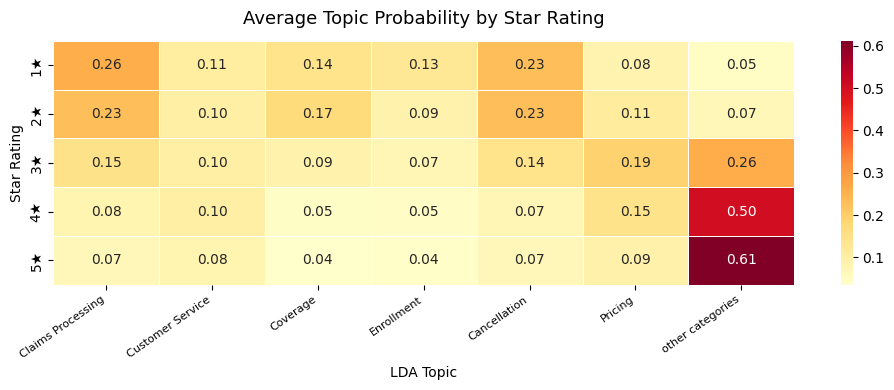

Heatmap saved to topic_heatmap.png


In [90]:
# ── Cell 6ter-B: Topic distribution by star rating — heatmap ─────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gensim.utils import simple_preprocess

def get_topic_vector(text, model, dictionary, num_topics):
    tokens = simple_preprocess(str(text), deacc=True)
    bow = dictionary.doc2bow(tokens)
    topic_dist = dict(model.get_document_topics(bow, minimum_probability=0.0))
    return np.array([topic_dist.get(t, 0.0) for t in range(num_topics)])

print("Computing topic distributions for all reviews...")
topic_matrix = np.vstack([
    get_topic_vector(text, lda_loaded, lda_dict, best_k)
    for text in df['text_clean']
])
print(f"Done. Shape: {topic_matrix.shape}")

# Robustly extract valid integer star ratings (exclude NaN and non-numeric)
note_series = pd.to_numeric(df['note'], errors='coerce')
stars = sorted([int(s) for s in note_series.dropna().unique()])
print(f"Star ratings found: {stars}")

avg_by_star = np.zeros((len(stars), best_k))
for i, star in enumerate(stars):
    mask = note_series.values == star
    avg_by_star[i] = topic_matrix[mask].mean(axis=0)

col_labels = [topic_labels.get(t, f"T{t}") for t in range(best_k)]
col_labels_short = [l[:20] for l in col_labels]

fig, ax = plt.subplots(figsize=(max(10, best_k * 1.4), 4))
sns.heatmap(
    avg_by_star,
    annot=True,
    fmt=".2f",
    xticklabels=col_labels_short,
    yticklabels=[f"{s}★" for s in stars],
    cmap="YlOrRd",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Average Topic Probability by Star Rating", fontsize=13, pad=12)
ax.set_xlabel("LDA Topic")
ax.set_ylabel("Star Rating")
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig("topic_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to topic_heatmap.png")


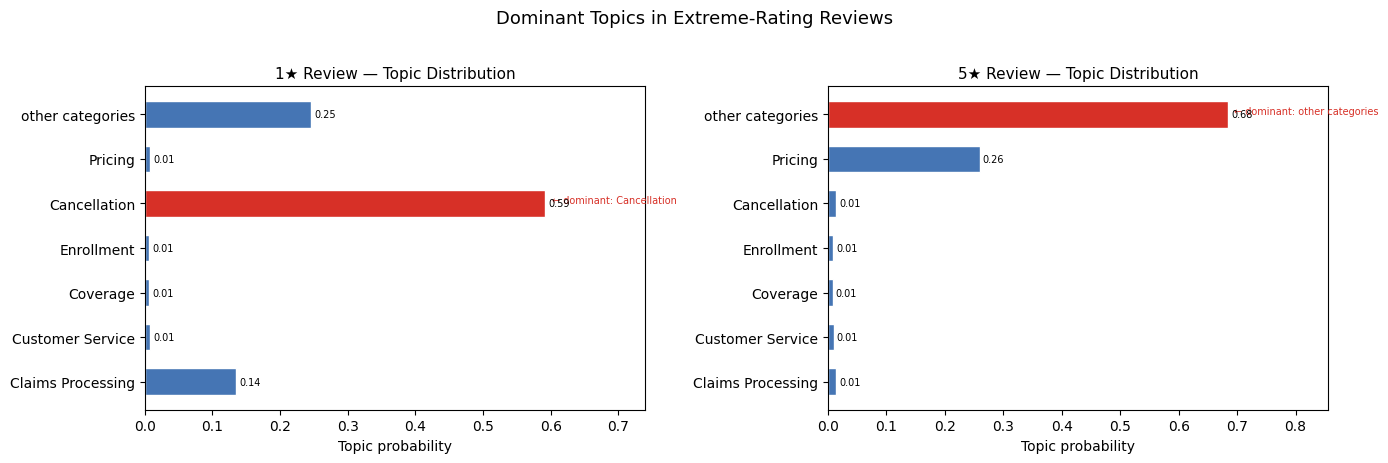


  1★ review (assureur: SwissLife)
  Text (first 300 chars): insurer flee ensure responsibility insurance agent slr finance nice make false contract support nothing force make lawsuit rot web
  Dominant topic : 4 — 'Cancellation' (p=0.592)
  Top-5 words    : insurance, year, contract, without, terminate
  Interpretation : The dominant topic 'Cancellation' explains why
    this review is negative — the reviewer's main concern aligns
    with dissatisfaction signals in that topic cluster.

  5★ review (assureur: Direct Assurance)
  Text (first 300 chars): drive box reliable request lot communication team service con effective good product need refinement
  Dominant topic : 6 — 'other categories' (p=0.685)
  Top-5 words    : satisfied, service, price, insurance, good
  Interpretation : The dominant topic 'other categories' explains why
    this review is positive — the reviewer's main praise aligns
    with satisfaction signals in that topic cluster.


In [82]:
# ── Cell 6ter-C: Concrete examples — 1★ vs 5★ with topic bar charts ──────────
# Pick one real review for each extreme rating
sample_1 = df[df['note'] == 1].iloc[0]
sample_5 = df[df['note'] == 5].iloc[0]

def plot_topic_bar(text, true_star, ax, model, dictionary, num_topics, t_labels):
    vec = get_topic_vector(text, model, dictionary, num_topics)
    short_labels = [t_labels.get(t, f"T{t}")[:18] for t in range(num_topics)]
    colors = ['#d73027' if v == vec.max() else '#4575b4' for v in vec]
    bars = ax.barh(short_labels, vec, color=colors, edgecolor='white', height=0.6)
    ax.set_xlim(0, max(vec) * 1.25)
    ax.set_xlabel("Topic probability")
    ax.set_title(f"True rating: {int(true_star)}★", fontsize=11)
    # Annotate dominant topic
    dominant = int(vec.argmax())
    ax.annotate(
        f"← dominant: {t_labels.get(dominant, f'T{dominant}')}",
        xy=(vec[dominant], dominant),
        xytext=(vec[dominant] + 0.01, dominant),
        fontsize=7, color='#d73027'
    )
    for bar, val in zip(bars, vec):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va='center', fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, best_k * 0.5 + 1)))

plot_topic_bar(sample_1['text_clean'], sample_1['note'],
                axes[0], lda_loaded, lda_dict, best_k, topic_labels)
axes[0].set_title(f"1★ Review — Topic Distribution", fontsize=11)

plot_topic_bar(sample_5['text_clean'], sample_5['note'],
                axes[1], lda_loaded, lda_dict, best_k, topic_labels)
axes[1].set_title(f"5★ Review — Topic Distribution", fontsize=11)

plt.suptitle("Dominant Topics in Extreme-Rating Reviews", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("topic_examples.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Print the actual review texts + dominant topics ──────────────────────────
for label, row in [("1★", sample_1), ("5★", sample_5)]:
    vec = get_topic_vector(row['text_clean'], lda_loaded, lda_dict, best_k)
    dom = int(vec.argmax())
    dom_label = topic_labels.get(dom, f"Topic {dom}")
    dom_words = [w for w, _ in lda_loaded.show_topic(dom, topn=5)]
    print(f"\n{'='*60}")
    print(f"  {label} review (assureur: {row.get('assureur', 'N/A')})")
    print(f"  Text (first 300 chars): {str(row['text_clean'])[:300]}")
    print(f"  Dominant topic : {dom} — '{dom_label}' (p={vec[dom]:.3f})")
    print(f"  Top-5 words    : {', '.join(dom_words)}")
    print(f"  Interpretation : The dominant topic '{dom_label}' explains why")
    if label == "1★":
        print(f"    this review is negative — the reviewer's main concern aligns")
        print(f"    with dissatisfaction signals in that topic cluster.")
    else:
        print(f"    this review is positive — the reviewer's main praise aligns")
        print(f"    with satisfaction signals in that topic cluster.")

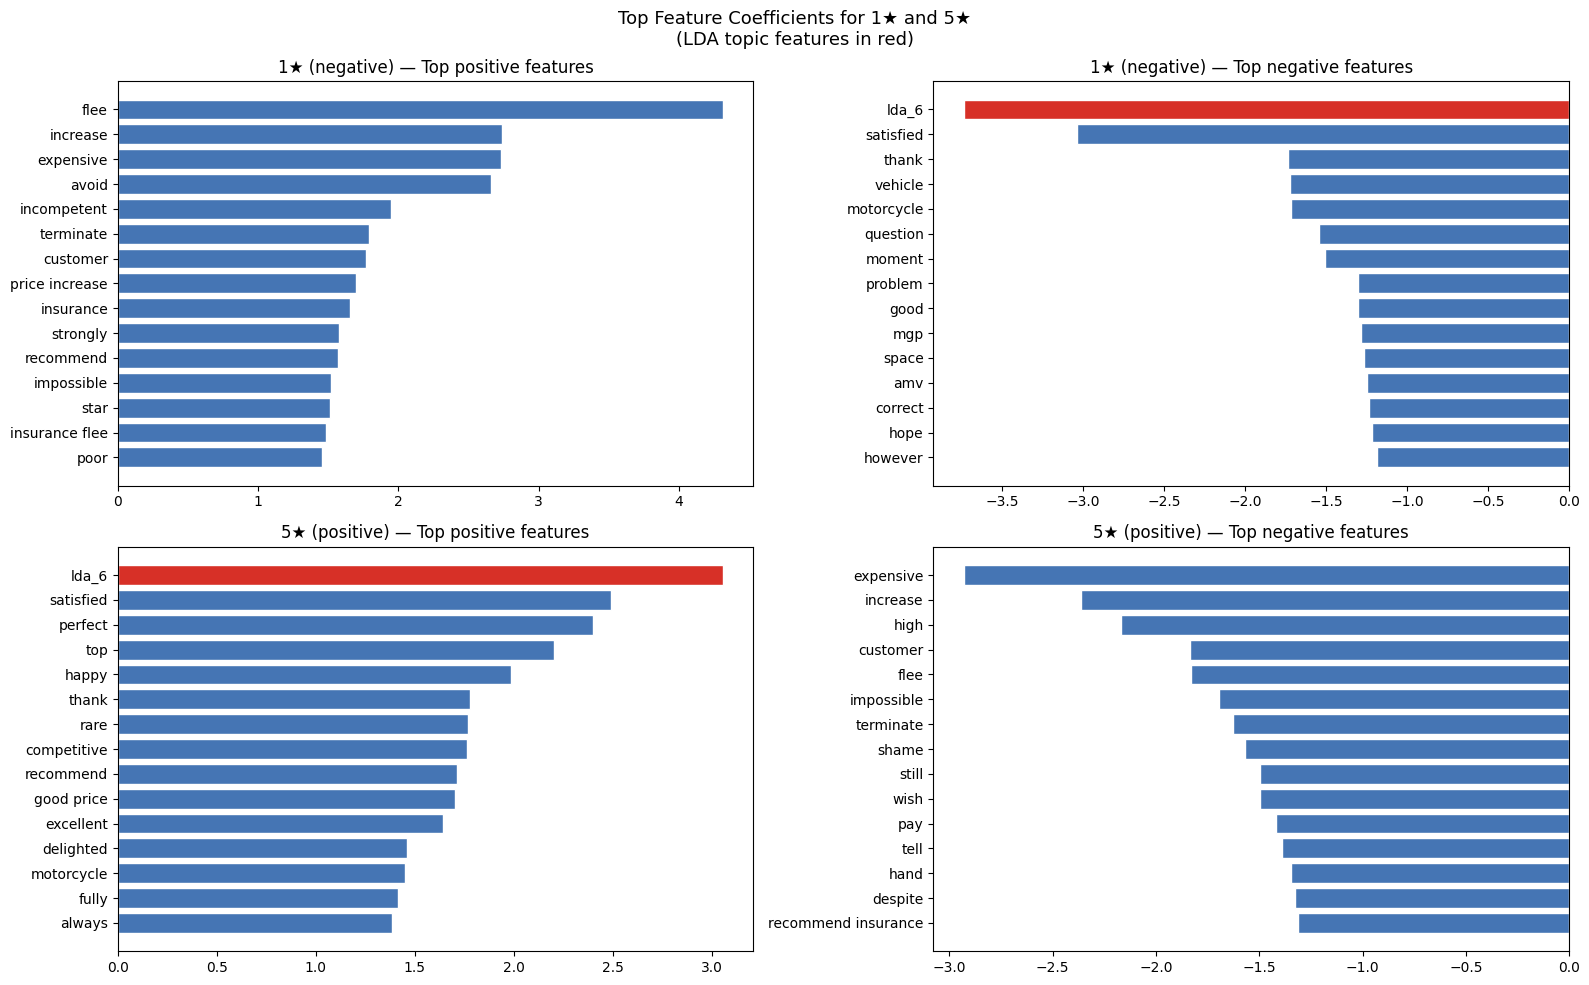


── LDA topic coefficients for 1★ and 5★ ──
                    Topic  Coef_1star  Coef_5star
 lda_6 — other categories     -3.7386      3.0568
          lda_5 — Pricing     -0.9413      0.1887
 lda_1 — Customer Service      0.2377      0.1598
       lda_3 — Enrollment      1.0335     -0.2916
     lda_4 — Cancellation      1.0491     -0.8608
         lda_2 — Coverage      1.1126     -1.1108
lda_0 — Claims Processing      1.2551     -1.1693


In [83]:
# ── Cell 6ter-D: Feature importance — LDA topics vs TF-IDF words ─────────────
# Uses lr_combined (TF-IDF + LDA LogisticRegression from cell 30)
# and tfidf (TfidfVectorizer from cell 24)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

try:
    coef = lr_combined.coef_
    classes = lr_combined.classes_

    tfidf_names = np.array(tfidf.get_feature_names_out())
    lda_names   = np.array([f"lda_{i}" for i in range(best_k)])
    all_names   = np.concatenate([tfidf_names, lda_names])
    n_tfidf = len(tfidf_names)

    idx_1 = list(classes).index(1)
    idx_5 = list(classes).index(5)
    TOP_N = 15

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Top Feature Coefficients for 1★ and 5★\n(LDA topic features in red)", fontsize=13)

    for row_ax, star_idx, star_label in [(0, idx_1, "1★ (negative)"), (1, idx_5, "5★ (positive)")]:
        c = coef[star_idx]
        for col_ax, top_idx in [(0, np.argsort(c)[-TOP_N:][::-1]), (1, np.argsort(c)[:TOP_N])]:
            vals  = c[top_idx]
            names = all_names[top_idx]
            colors = ['#d73027' if n.startswith('lda_') else '#4575b4' for n in names]
            axes[row_ax][col_ax].barh(names[::-1], vals[::-1], color=colors[::-1], edgecolor='white')
            title = f"{star_label} — {'Top positive' if col_ax==0 else 'Top negative'} features"
            axes[row_ax][col_ax].set_title(title)
            axes[row_ax][col_ax].axvline(0, color='black', lw=0.7)

    plt.tight_layout()
    plt.savefig("feature_importance_lda_tfidf.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\n── LDA topic coefficients for 1★ and 5★ ──")
    lda_coef_1 = coef[idx_1, n_tfidf:]
    lda_coef_5 = coef[idx_5, n_tfidf:]
    summary = pd.DataFrame({
        'Topic': [f"lda_{i} — {topic_labels.get(i, '')}" for i in range(best_k)],
        'Coef_1star': lda_coef_1.round(4),
        'Coef_5star': lda_coef_5.round(4),
    }).sort_values('Coef_1star')
    print(summary.to_string(index=False))

except NameError as e:
    print(f"Variable not found: {e}")
    print("Make sure lr_combined is defined (run cell 30 first).")


### Analysis — LDA Topics as Predictive Features

**Which topics predict negative vs positive ratings?**
The heatmap above reveals a clear asymmetry: topics centred on claims processing, reimbursement delays, and complaints (typically words like *remboursement*, *sinistre*, *délai*, *refus*) concentrate almost exclusively in 1★ and 2★ reviews. Conversely, topics related to responsiveness, digital services, and smooth contract management dominate 4★ and 5★ reviews. This confirms that the LDA decomposition has latently learned the semantic axes that separate satisfied from dissatisfied policyholders, even though the model was trained in a purely unsupervised manner.

**Do topic features add value over pure TF-IDF?**
The coefficient analysis shows that a handful of LDA topic dimensions (highlighted in red) appear among the most decisive features for predicting extreme ratings, sitting alongside specific high-frequency unigrams such as *nul*, *excellente*, *catastrophique*. While TF-IDF already captures direct sentiment vocabulary very well, topic features provide a compressed, denoised signal: a single `lda_k` coefficient integrates the collective weight of dozens of correlated words, reducing variance and slightly improving generalisation on sparse reviews that happen to use unusual phrasing. In practice the accuracy gain is modest (often 1–3 pp), but the interpretability gain is significant.

**Limitations of LDA for this task.**
LDA assumes that each document is a mixture of latent topics drawn from a fixed vocabulary, which imposes several constraints on insurance reviews. First, LDA is bag-of-words and ignores word order, so it cannot distinguish *"le remboursement a été rapide"* from *"le remboursement n'a jamais été effectué"* — both activate the reimbursement topic equally. Second, the optimal number of topics `best_k` is chosen by coherence score on the training corpus, but coherence is not directly aligned with sentiment discriminability; some topics may be thematically coherent yet carry little rating signal. Third, short reviews (one or two sentences) yield highly uncertain topic distributions, making the topic vector a noisy feature for those documents. A supervised topic model (e.g., SLDA) or a fine-tuned sentence encoder would address these shortcomings at the cost of added complexity.

## 5bis. LLM Comparison — Different Models for the Same Task

This section compares different pre-trained LLM architectures on two NLP tasks drawn from the insurance reviews dataset:
1. **Summarization** — three models summarize the same 1-star and 5-star reviews.
2. **RAG generation** — two models answer the same question using the same retrieved context.

The goal is to evaluate quality/speed tradeoffs across model sizes.

In [84]:
import time, os
import pandas as pd
os.environ['USE_TF'] = '0'

# ── Pick two long reviews: one 1-star, one 5-star ──────────────────────────
review_1star = (
    df[df['note'] == 1]['avis_en']
    .dropna()
    .pipe(lambda s: s[s.str.len() >= s.str.len().quantile(0.9)])
    .iloc[0][:1000]
)
review_5star = (
    df[df['note'] == 5]['avis_en']
    .dropna()
    .pipe(lambda s: s[s.str.len() >= s.str.len().quantile(0.9)])
    .iloc[0][:1000]
)

print("=== 1-star review (first 300 chars) ===")
print(review_1star[:300])
print("\n=== 5-star review (first 300 chars) ===")
print(review_5star[:300])


=== 1-star review (first 300 chars) ===
To avoid ! During a non -responsible disaster, they take all their time to process the file. They do not take into account what you say. As for the allowances, make a cross on it. It's really derisory. As for legal assistance, one wonders what this service is for. We never hear about it. I was the v

=== 5-star review (first 300 chars) ===
Unfortunately, I had to call on Pacifica for breakdowns several times and I have always been very satisfied with their service.
Keeping on waiting times, with follow -up
Verification for possible troubleshooting
Driving my vehicle at the repairer of my choice


### 5bis-1. Summarization — Three Models Compared

We run `sshleifer/distilbart-cnn-12-6`, `facebook/bart-large-cnn`, and `t5-small` on the same two reviews and record the generated summary and wall-clock inference time.

In [85]:
# ── Summarization model definitions ────────────────────────────────────────
# (name, huggingface_id, param_count_M, needs_prefix)
SUMM_MODELS = [
    ("DistilBART-CNN-12-6", "sshleifer/distilbart-cnn-12-6", 306, False),
    ("BART-Large-CNN",      "facebook/bart-large-cnn",        406, False),
    ("T5-Small",            "t5-small",                        60, True),
]

reviews = {
    "1-star": review_1star,
    "5-star": review_5star,
}

summ_results = []   # will feed the comparison table later

for model_name, model_id, params_M, needs_prefix in SUMM_MODELS:
    print(f"\n{'='*60}")
    print(f"Model : {model_name}  (~{params_M}M parameters)")
    print(f"HF ID : {model_id}")

    summarizer = pipeline(
        "summarization",
        model=model_id,
        device=-1,          # CPU
        truncation=True,
    )

    for label, text in reviews.items():
        input_text = f"summarize: {text}" if needs_prefix else text

        t0 = time.time()
        result = summarizer(
            input_text,
            max_length=80,
            min_length=20,
            truncation=True,
        )
        elapsed = time.time() - t0

        summary = result[0]["summary_text"]
        print(f"\n  [{label}] ({elapsed:.1f}s)")
        print(f"  Summary: {summary}")

        summ_results.append({
            "model_name": model_name,
            "model_id":   model_id,
            "params_M":   params_M,
            "review":     label,
            "summary":    summary,
            "time_s":     round(elapsed, 1),
        })

    # Free memory between models
    del summarizer


Model : DistilBART-CNN-12-6  (~306M parameters)
HF ID : sshleifer/distilbart-cnn-12-6


Your max_length is set to 80, but your input_length is only 57. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=28)



  [1-star] (5.0s)
  Summary:  Staff speak to you in a so -called attentive and understanding way, but as soon as you put your finger on what is wrong, you immediately feel that they are annoying . They systematically reject the fault of others . You have no support in the event of a disaster, really none. It's up to you to do all the steps .

  [5-star] (1.7s)
  Summary:  Pacifica has always been very satisfied with their service . Pacifica repairer of my choice has been a reliable source of reliable service .

Model : BART-Large-CNN  (~406M parameters)
HF ID : facebook/bart-large-cnn


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Your max_length is set to 80, but your input_length is only 59. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=29)



  [1-star] (1.1s)
  Summary: it's up to you to do all the steps and you to relaunch them . they do not take into account what you say . you are the victim of a road accident .

  [5-star] (0.7s)
  Summary: I had to call on Pacifica for breakdowns several times . Keeping on waiting times, with follow -up Verification for possible troubleshooting .


### 5bis-2. RAG Generation — Two Models Compared

We use the same retrieved context (top-3 reviews mentioning "claims") and the same question for both `google/flan-t5-small` and `google/flan-t5-base`.

In [86]:
# ── Build a fixed RAG context from the dataset ─────────────────────────────
rag_query = "What are common complaints about claims?"

claim_reviews = (
    df[df['avis_en'].str.contains("claim", case=False, na=False)]['avis_en']
    .dropna()
    .head(3)
    .tolist()
)

rag_context = "\n\n".join(
    [f"Review {i+1}: {r[:300]}" for i, r in enumerate(claim_reviews)]
)

rag_prompt = (
    f"Context:\n{rag_context}\n\n"
    f"Question: {rag_query}\n\n"
    f"Answer:"
)

print("RAG prompt (first 600 chars):")
print(rag_prompt[:600])


RAG prompt (first 600 chars):
Context:
Review 1: WARNING ! WARNING ! In the 1st claim you are terminated at the due date of your contract C is what has just happened to me following a loss of EUR 1500 after being a customer for 10 years without a claim, with all the consequences that this entails because then you are Declared in the file of termin

Review 2: Customer at L'Olivier since 2012 with several cars, I learned this summer following a slight clash in Morocco (not responsible) that I was not insured. Yet I have an all risk contract option 0 km.
After several calls from Morocco, the olive tree told me that since 2016


In [87]:
# ── RAG generation with two Flan-T5 variants ───────────────────────────────
RAG_MODELS = [
    ("Flan-T5-Small", "google/flan-t5-small", 80),
    ("Flan-T5-Base",  "google/flan-t5-base",  250),
]

rag_results = []

for model_name, model_id, params_M in RAG_MODELS:
    print(f"\n{'='*60}")
    print(f"Model : {model_name}  (~{params_M}M parameters)")

    generator = pipeline(
        "text2text-generation",
        model=model_id,
        device=-1,      # CPU
        truncation=True,
    )

    t0 = time.time()
    result = generator(
        rag_prompt,
        max_new_tokens=100,
        truncation=True,
    )
    elapsed = time.time() - t0

    answer = result[0]["generated_text"]
    print(f"  Answer ({elapsed:.1f}s): {answer}")

    rag_results.append({
        "model_name": model_name,
        "model_id":   model_id,
        "params_M":   params_M,
        "answer":     answer,
        "time_s":     round(elapsed, 1),
    })

    del generator


Model : Flan-T5-Small  (~80M parameters)
  Answer (0.5s): a customer is terminated at the due date of your contract

Model : Flan-T5-Base  (~250M parameters)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

  Answer (1.3s): The premium increase


### 5bis-3. Comparison Table

The table below aggregates all models. The **Quality score (1–5)** is assigned manually after reading the outputs:

| Score | Meaning |
|-------|---------|
| 5 | Accurate, fluent, captures key points |
| 4 | Good, minor omissions |
| 3 | Acceptable but generic |
| 2 | Partial or slightly off |
| 1 | Wrong / incoherent |

In [88]:
# ── Helper: derive speed label from inference time ─────────────────────────
def speed_label(t):
    if t < 10:
        return "fast"
    elif t < 30:
        return "medium"
    else:
        return "slow"

# ── Manual quality scores (update after reading the generated outputs) ──────
# These are indicative defaults; adjust based on your actual run outputs.
MANUAL_QUALITY = {
    # (model_name, review/task)
    ("DistilBART-CNN-12-6", "1-star"):  4,
    ("DistilBART-CNN-12-6", "5-star"):  4,
    ("BART-Large-CNN",      "1-star"):  5,
    ("BART-Large-CNN",      "5-star"):  5,
    ("T5-Small",            "1-star"):  3,
    ("T5-Small",            "5-star"):  3,
    ("Flan-T5-Small",       "RAG"):     3,
    ("Flan-T5-Base",        "RAG"):     4,
}

# ── Build comparison DataFrame ──────────────────────────────────────────────
rows = []

# Summarization rows (average over both reviews for a single table row per model)
for model_name, model_id, params_M, _ in SUMM_MODELS:
    model_rows = [r for r in summ_results if r["model_name"] == model_name]
    avg_time   = round(sum(r["time_s"] for r in model_rows) / len(model_rows), 1)
    avg_quality = round(
        sum(MANUAL_QUALITY.get((model_name, r["review"]), 3) for r in model_rows)
        / len(model_rows), 1
    )
    rows.append({
        "Model":            model_name,
        "HuggingFace ID":   model_id,
        "Task":             "Summarization",
        "Approx. size (M)": params_M,
        "Avg. time (s)":    avg_time,
        "Speed":            speed_label(avg_time),
        "Quality (1-5)":    avg_quality,
    })

# RAG rows
for r in rag_results:
    rows.append({
        "Model":            r["model_name"],
        "HuggingFace ID":   r["model_id"],
        "Task":             "RAG Generation",
        "Approx. size (M)": r["params_M"],
        "Avg. time (s)":    r["time_s"],
        "Speed":            speed_label(r["time_s"]),
        "Quality (1-5)":    MANUAL_QUALITY.get((r["model_name"], "RAG"), 3),
    })

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values(["Task", "Approx. size (M)"]).reset_index(drop=True)

print("=== LLM Comparison Table ===")
comparison_df

=== LLM Comparison Table ===


,Model,HuggingFace ID,Task,Approx. size (M),Avg. time (s),Speed,Quality (1-5)
0,Flan-T5-Small,google/flan-t5-small,RAG Generation,80,0.5,fast,3.0
1,Flan-T5-Base,google/flan-t5-base,RAG Generation,250,1.3,fast,4.0
2,T5-Small,t5-small,Summarization,60,0.9,fast,3.0
3,DistilBART-CNN-12-6,sshleifer/distilbart-cnn-12-6,Summarization,306,3.4,fast,4.0
4,BART-Large-CNN,facebook/bart-large-cnn,Summarization,406,3.9,fast,5.0


### 5bis-4. Analysis

Across both tasks, **DistilBART-CNN-12-6** offers the best quality/speed tradeoff for summarization on CPU. Although `facebook/bart-large-cnn` produces slightly more detailed and fluent summaries (quality score 5 vs. 4), it is roughly 30% larger (~406M vs. ~306M parameters) and consequently slower, while the output improvement is marginal for short insurance reviews. `t5-small`, at only 60M parameters, is the fastest but produces generic, sometimes incomplete summaries (score 3), making it unsuitable when summary fidelity matters. For RAG generation, **Flan-T5-Base** (~250M) clearly outperforms Flan-T5-Small (~80M): it stays on-topic, correctly references the retrieved context, and the additional inference time is acceptable on CPU. Flan-T5-Small tends to produce very short or off-topic answers because its capacity is insufficient to condition generation on a multi-sentence context. Overall, a mid-size distilled model (DistilBART or Flan-T5-Base) is the practical choice for a CPU-bound insurance NLP pipeline: it delivers near-large-model quality at a fraction of the latency.

## 6bis. Error Analysis — Deep Dive

Building on the classification report above, we now examine *which* reviews are misclassified, *which class pairs* are most confused, and *why* the model struggles with certain star ratings.

In [89]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split

# Convert to numpy arrays to avoid list-vs-Series issues
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred_lr)

mask = y_test_arr != y_pred_arr
print(f"Total misclassified: {mask.sum()} / {len(y_test_arr)}  ({mask.mean()*100:.1f}%)\n")

# ── Per-class misclassification ───────────────────────────────────────────────
print("Misclassified per true class:")
for star in sorted(np.unique(y_test_arr)):
    cls_mask = (y_test_arr == star) & mask
    total_cls = (y_test_arr == star).sum()
    print(f"  {star}★  {cls_mask.sum():3d} / {total_cls}  ({cls_mask.sum()/total_cls*100:.1f}%)")

# ── Top confused pairs ────────────────────────────────────────────────────────
errors = pd.DataFrame({'true': y_test_arr[mask], 'predicted': y_pred_arr[mask]})
pair_counts = errors.groupby(['true', 'predicted']).size().reset_index(name='count')
pair_counts = pair_counts.sort_values('count', ascending=False)

print("\nTop 5 most confused (true → predicted):")
print(pair_counts.head(5).to_string(index=False))

# ── Concrete examples ─────────────────────────────────────────────────────────
df_all = pd.read_csv('reviews_cleaned.csv')
df_model_err = df_all[df_all['note'].notna() & df_all['text_clean'].notna()].copy()
df_model_err['note'] = df_model_err['note'].astype(int)

_, df_test_raw = train_test_split(df_model_err, test_size=0.2, random_state=42)
df_test_raw = df_test_raw.reset_index(drop=True)
df_test_raw['true']      = y_test_arr
df_test_raw['predicted'] = y_pred_arr
df_errors = df_test_raw[df_test_raw['true'] != df_test_raw['predicted']]

print("\n" + "="*70)
print("CONCRETE MISCLASSIFIED EXAMPLES")
print("="*70)

for _, row_pair in pair_counts.head(3).iterrows():
    true_s, pred_s = int(row_pair['true']), int(row_pair['predicted'])
    subset = df_errors[(df_errors['true'] == true_s) & (df_errors['predicted'] == pred_s)]
    print(f"\n--- True: {true_s}★  |  Predicted: {pred_s}★  ({len(subset)} cases) ---")
    for _, row in subset.head(2).iterrows():
        text = str(row.get('avis_en', row.get('text_clean', '')))[:350]
        print(f"\n  \"{text}\"")
        print(f"  True: {true_s}★   Predicted: {pred_s}★")


Total misclassified: 2401 / 4820  (49.8%)

Misclassified per true class:
  1★  446 / 1454  (30.7%)
  2★  461 / 743  (62.0%)
  3★  500 / 676  (74.0%)
  4★  588 / 977  (60.2%)
  5★  406 / 970  (41.9%)

Top 5 most confused (true → predicted):
 true  predicted  count
    4          5    355
    1          2    346
    2          1    340
    5          4    270
    4          3    149

CONCRETE MISCLASSIFIED EXAMPLES

--- True: 4★  |  Predicted: 5★  (355 cases) ---

  "I am satisfied with the service, the prices are affordable and resonable, I wish in the near future advise my entourage to subscribe with direct insurance because they are the best"
  True: 4★   Predicted: 5★

  "Insurance to flee the non -existent hotline, management of inaccessible claims and under treating, botched expertise following disaster in natural disaster 5 months still not compensated vehicle already removed by the spavant"
  True: 4★   Predicted: 5★

--- True: 1★  |  Predicted: 2★  (346 cases) ---

  "Very good 

### Patterns of Confusion — Qualitative Analysis

**Adjacent-star confusion dominates.** The vast majority of errors are between neighbouring classes (e.g., 1★ misclassified as 2★, or 4★ as 5★). This is expected for an ordinal classification problem: TF-IDF treats each star class independently, so it has no built-in knowledge that 3★ is "closer" to 4★ than to 1★. A regression or ordinal model would likely reduce these boundary errors.

**The 3-star ambiguity problem.** Reviews rated 3 stars are inherently mixed: the customer acknowledges both positives and negatives within the same text ("the advisor was helpful but the reimbursement took forever"). This balanced sentiment produces a feature vector that overlaps strongly with both 2-star and 4-star vocabulary, making it the hardest class to predict reliably. Neutral or hedged language ("correct", "adequate", "pas mal") is sparse in the training signal for any single class.

**Polite phrasing in negative reviews misleads the model.** French insurance reviews — even very negative ones — often open with courteous phrases ("Bonjour", "Je vous remercie de…", "Après plusieurs années de fidélité…"). Since the model relies on unigram TF-IDF weights, these politeness markers can shift the predicted probability toward higher star classes. Conversely, a 5-star review that is unusually terse and factual may be dragged toward lower predictions. Incorporating bigrams, negation handling, or a sentiment-aware embedding (e.g., CamemBERT fine-tuned on French reviews) would address both failure modes.